In [2]:
import os
from google.colab import drive
drive.mount('/content/drive')

#Define the folder where the data is stored
output_path = '/content/drive/MyDrive/'
filepath = os.path.join(output_path, 'panel_all_years_sampled.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#**LOGISTIC REGRESSION + W&B + FAIRNESS + FEATURE ENGINEERING**

Using device: cuda


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: alessia-ciccaglione02 (ADSP-HYPE) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Loading data...
  Righe caricate: 3,792,126
  Loan unici:     99,970
  applicant_sex valid: 3,463,129 (91.3%)
  applicant_race valid: 3,070,019 (81.0%)
  applicant_age valid: 3,791,787 (100.0%)

[CHECK] Composizione dataset:
  Loan totali:    99,970
  Defaulters:     9,997 (10.0%)
  Non-defaulters: 89,973 (90.0%)

Computing BD_pct...
  bd_pct: NaN=34,464  mean=-0.0265  std=0.1095
  ltv_ratio: Inf=0  NaN=34187
  rate_ratio: Inf=0  NaN=34187
  upb_ratio: Inf=0  NaN=34464

Dummy features — mean values:
  cs_lt_620: 0.001
  cs_lt_660: 0.047
  ltv_gt_80: 0.132
  ltv_gt_95: 0.072
  dti_gt_43: 0.230

Fitting splines on ['credit_score', 'estimated_ltv', 'original_dti', 'upb_ratio']...
  Spline features aggiunte: 24

Building PERSON-PERIOD dataset...
  Righe: 3,443,703 | Default: 9991 (0.29%)

[CHECK] Mediane imputation PP (prime 5):
credit_score     764.00
original_dti      36.00
original_ltv      68.00
interest_rate      3.25
loan_term        360.00

[CHECK] X_pp:
  shape=(3443703, 46)  dtype

/tmp/ipykernel_11579/621307310.py:731: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/tmp/ipykernel_11579/621307310.py:732: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(OUT_DIR / "diag_calibrazione_pp.png", dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


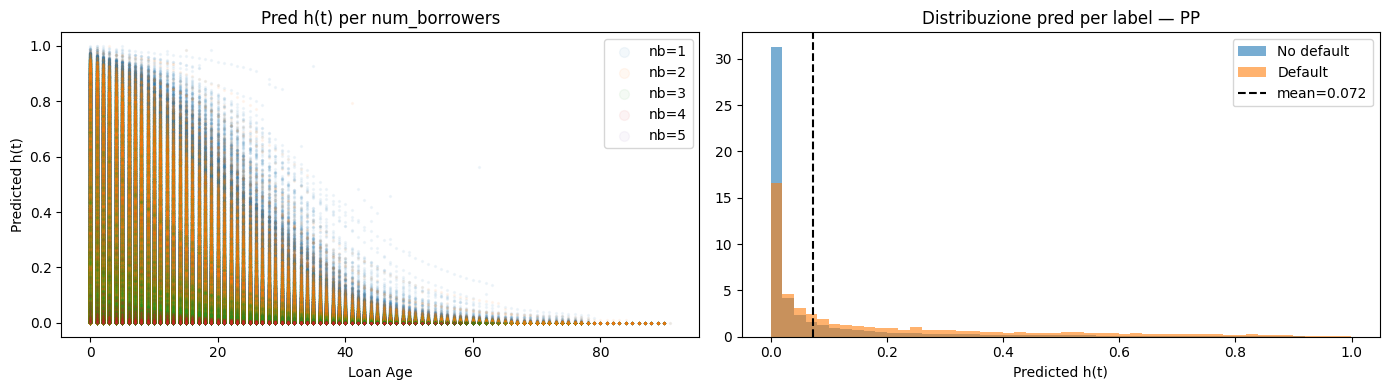


Top-15 features by |coefficient| (M_PP):
estimated_ltv_sp5      0.550636
credit_score_sp3       0.533359
credit_score_sp5       0.515771
upb_ratio_sp0          0.504150
estimated_ltv_sp4      0.479800
upb_ratio_sp2          0.452097
original_ltv           0.434627
upb_ratio_sp1          0.415633
credit_score_sp4       0.374755
credit_score_sp1       0.372781
loan_age_sp1           0.367430
original_dti_sp4       0.358345
upb_ratio_sp4          0.337644
loan_purpose_orig_N    0.331204
bd_pct                 0.326802

[CHECK] log1p_loan_age raw coef = -0.221299  (atteso: negativo)
[CHECK] bd_pct          raw coef = 0.326802   (atteso: positivo)

Spline importance aggregata:
credit_score_SPLINE     2.416953
upb_ratio_SPLINE        2.289147
estimated_ltv_SPLINE    1.739646
original_dti_SPLINE     1.372885


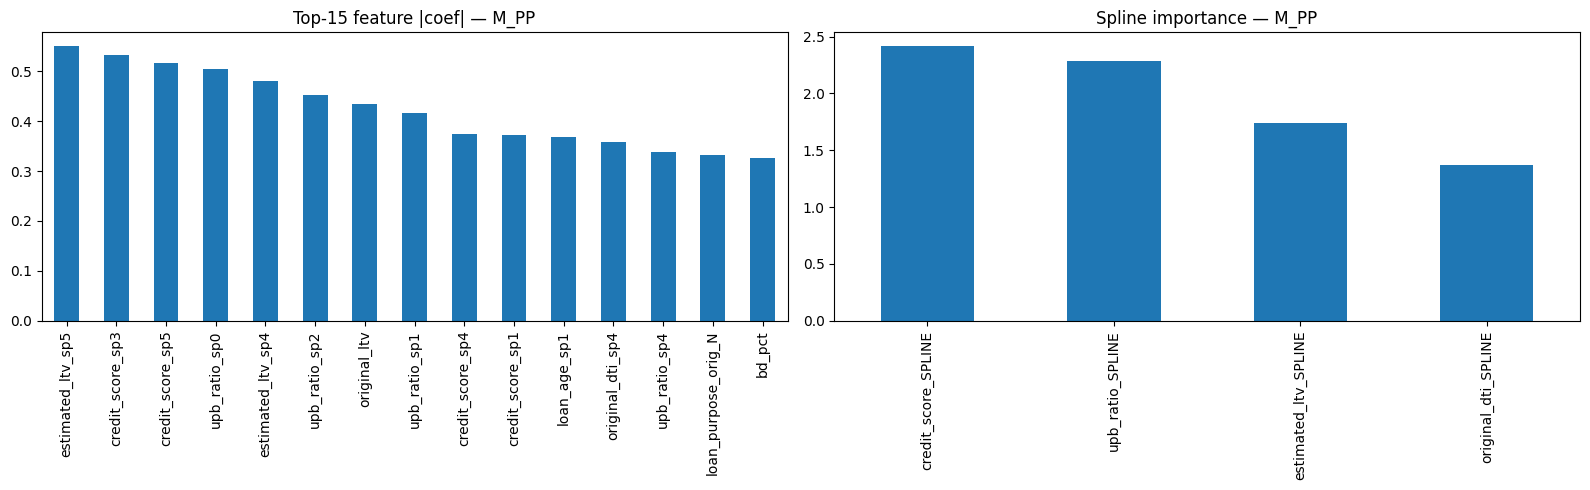

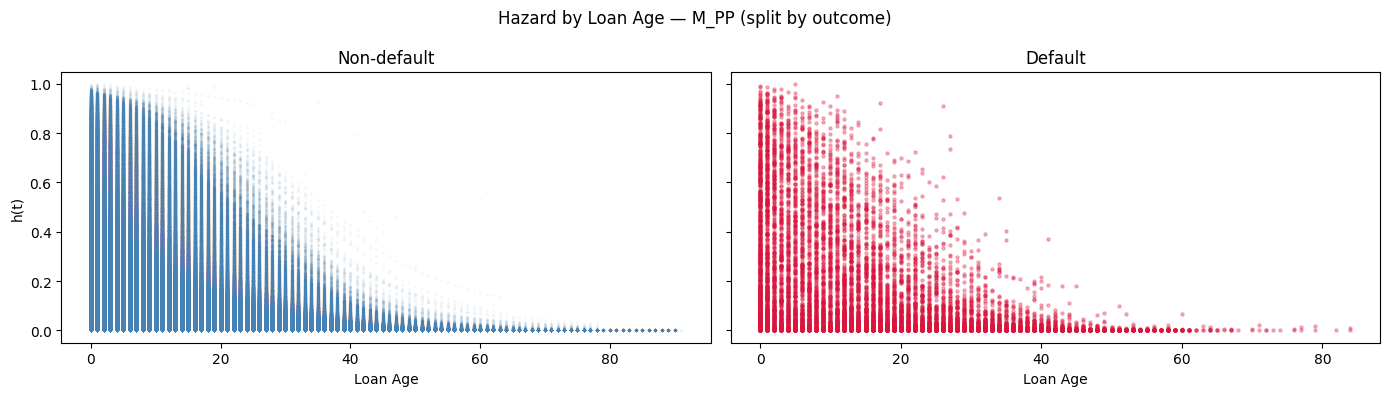

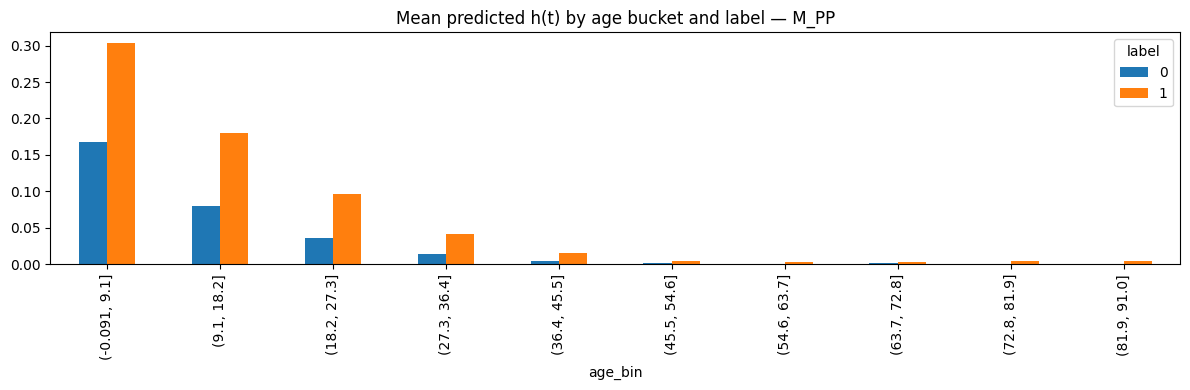


=== RISULTATI FINALI ===
    Model  AUC_Mean   AUC_SD  Brier_Mean  Brier_SD  F1_Mean    F1_SD  Time_Mean_sec  Time_SD_sec
 M_STATIC  0.610333 0.010495    0.056533  0.002571 0.109273 0.006042       3.878855     3.004543
M_DYNAMIC  0.716439 0.004300    0.086861  0.002155 0.132868 0.004942       3.043789     0.167429
     M_PP  0.696810 0.005470    0.029678  0.000629 0.015669 0.000583       7.786417     0.058727

=== DINAMICO — AUC PER LANDMARK ===
 Landmark  AUC_Mean  Brier_Mean  F1_Mean
        0  0.679721    0.185520 0.144973
        3  0.698395    0.144662 0.143315
        6  0.698740    0.131297 0.140155
        9  0.696544    0.119813 0.135144
       12  0.693931    0.116547 0.124286
       15  0.705748    0.098766 0.124825
       18  0.706168    0.090157 0.114994
       21  0.704993    0.080688 0.105336
       24  0.706580    0.071449 0.103004
       27  0.711087    0.059203 0.093897
       30  0.716475    0.047373 0.101180
       33  0.702018    0.032840 0.062112
       36  0.705

M_DYNAMIC/AGE/auc_gap,▁
M_DYNAMIC/AGE/dp_gap,▁
M_DYNAMIC/AGE/fpr_gap,▁
M_DYNAMIC/AGE/group_Old/auc,▁
M_DYNAMIC/AGE/group_Old/dp,▁
M_DYNAMIC/AGE/group_Old/fnr,▁
M_DYNAMIC/AGE/group_Old/fpr,▁
M_DYNAMIC/AGE/group_Old/mean_score,▁
M_DYNAMIC/AGE/group_Old/ppv,▁
M_DYNAMIC/AGE/group_Old/prev,▁
+230,...


In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings, time, gc, os
from sklearn.preprocessing import OneHotEncoder, StandardScaler, SplineTransformer
from sklearn.metrics import roc_auc_score, brier_score_loss, f1_score, precision_recall_curve
from sklearn.model_selection import GroupKFold
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

np.random.seed(42)
torch.manual_seed(42)
warnings.filterwarnings("ignore", category=FutureWarning)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# ── UNICO PARAMETRO DA CAMBIARE ────────────────────────────────────────────────
DATA_PATH = filepath # <-- sostituisci con il tuo path
OUT_DIR   = Path("/content/out")
OUT_DIR.mkdir(parents=True, exist_ok=True)

HORIZON_MONTHS = 12
LANDMARKS      = [0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 36, 39, 42, 45, 48]



import wandb

FAIR_ALPHA = 1000
FAIR_ATTR  = "RACE"

wandb.init(
    entity="alessia-ciccaglione02-",
    # Set the wandb project where this run will be logged.
    project="ThesisFairness",
    name    = f"LR_{FAIR_ATTR}_alpha{FAIR_ALPHA}",
    config  = {
        "model_type":     "LogisticRegression",
        "fair_attr":      FAIR_ATTR,
        "fair_alpha":     FAIR_ALPHA,
        "apply_fair":     FAIR_ALPHA > 0,
        "lr":             1e-3,
        "n_epochs":       500,
        "pos_weight_cap": 110.0,
        "n_folds":        5,
        "horizon_months": HORIZON_MONTHS,
        "n_knots":        5,
    }
)


import torch
from torch import nn
from torch.nn import functional as F


class ConstraintLoss(nn.Module):
    def __init__(self, n_class=2, alpha=1, p_norm=2):
        super(ConstraintLoss, self).__init__()
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.alpha = alpha
        self.p_norm = p_norm
        self.n_class = n_class
        self.n_constraints = 2
        self.dim_condition = self.n_class + 1
        self.M = torch.zeros((self.n_constraints, self.dim_condition))
        self.c = torch.zeros(self.n_constraints)

    def mu_f(self, X=None, y=None, sensitive=None):
        return torch.zeros(self.n_constraints)

    def forward(self, X, out, sensitive, y=None):
        sensitive = sensitive.view(out.shape)
        if isinstance(y, torch.Tensor):
            y = y.view(out.shape)
        out = torch.sigmoid(out)
        mu = self.mu_f(X=X, out=out, sensitive=sensitive, y=y)
        gap_constraint = F.relu(
            torch.mv(self.M.to(self.device), mu.to(self.device)) - self.c.to(self.device)
        )
        if self.p_norm == 2:
            cons = self.alpha * torch.dot(gap_constraint, gap_constraint)
        else:
            cons = self.alpha * torch.dot(gap_constraint.detach(), gap_constraint)
        return cons

class EqualiedOddsLoss(ConstraintLoss):
    def __init__(self, sensitive_classes=[0, 1], alpha=1, p_norm=2):
        """loss of demograpfhic parity

        Args:
            sensitive_classes (list, optional): list of unique values of sensitive attribute. Defaults to [0, 1].
            alpha (int, optional): [description]. Defaults to 1.
            p_norm (int, optional): [description]. Defaults to 2.
        """
        self.sensitive_classes = sensitive_classes
        self.y_classes = [0, 1]
        self.n_class = len(sensitive_classes)
        self.n_y_class = len(self.y_classes)
        super(EqualiedOddsLoss, self).__init__(n_class=self.n_class, alpha=alpha, p_norm=p_norm)
        # K:  number of constraint : (|A| x |Y| x {+, -})
        self.n_constraints = self.n_class * self.n_y_class * 2
        # J : dim of conditions  : ((|A|+1) x |Y|)
        self.dim_condition = self.n_y_class * (self.n_class + 1)
        self.M = torch.zeros((self.n_constraints, self.dim_condition))
        # make M (K * J): (|A| x |Y| x {+, -})  *   (|A|+1) x |Y|) )
        self.c = torch.zeros(self.n_constraints)
        element_K_A = self.sensitive_classes + [None]
        for i_a, a_0 in enumerate(self.sensitive_classes):
            for i_y, y_0 in enumerate(self.y_classes):
                for i_s, s in enumerate([-1, 1]):
                    for j_y, y_1 in enumerate(self.y_classes):
                        for j_a, a_1 in enumerate(element_K_A):
                            i = i_a * (2 * self.n_y_class) + i_y * 2 + i_s
                            j = j_y + self.n_y_class * j_a
                            self.M[i, j] = self.__element_M(a_0, a_1, y_1, y_1, s)

    def __element_M(self, a0, a1, y0, y1, s):
        if a0 is None or a1 is None:
            x = y0 == y1
            return -1 * s * x
        else:
            x = (a0 == a1) & (y0 == y1)
            return s * float(x)

    def mu_f(self, X, out, sensitive, y):
        expected_values_list = []
        for u in self.sensitive_classes:
            for v in self.y_classes:
                idx_true = (y == v) * (sensitive == u)  # torch.bool
                expected_values_list.append(out[idx_true].mean())
        # sensitive is star
        for v in self.y_classes:
            idx_true = y == v
            expected_values_list.append(out[idx_true].mean())
        return torch.stack(expected_values_list)

    def forward(self, X, out, sensitive, y):
        return super(EqualiedOddsLoss, self).forward(X, out, sensitive, y=y)


# ── Helpers ────────────────────────────────────────────────────────────────────
def is_default_vec(s):
    num = pd.to_numeric(s, errors="coerce")
    return (num.notna() & (num != 0)).astype(np.int8)

def scheduled_balance(orig_upb, r, N, a):
    """
    Saldo teorico al mese a secondo il piano di ammortamento originale.
    r = tasso annuo (percentuale o decimale), N = mesi totali, a = mese corrente.
    """
    try:
        orig_upb = float(orig_upb); r = float(r)
        N = int(float(N));          a = float(a)
    except:
        return np.nan
    if any(np.isnan(x) for x in [orig_upb, r, N, a]):
        return np.nan
    if r > 1:
        r /= 100.0
    if r < 0 or N <= 0 or N > 1000:
        return np.nan
    rm = r / 12.0
    if abs(rm) < 1e-10:
        return max(0.0, orig_upb - (orig_upb / N) * a)
    a = np.clip(a, 0, N)
    try:
        num = (1 + rm)**N - (1 + rm)**a
        den = (1 + rm)**N - 1
        return max(0.0, orig_upb * num / den) if den != 0 else np.nan
    except OverflowError:
        return np.nan

def compute_bd_pct(cur_upb, sched):
    """
    Balance Deviation %: (saldo_corrente - saldo_teorico) / saldo_teorico.
    Positivo = mutuatario in ritardo rispetto al piano (segnale di rischio).
    Negativo = ha pagato più del previsto.
    """
    if pd.isna(cur_upb) or pd.isna(sched) or sched <= 1:
        return np.nan
    return (cur_upb - sched) / sched

def find_best_threshold(y_true, p, max_th_quantile=0.90):
    """Soglia ottimale su F1, limitata al 90° percentile degli score."""
    p = np.clip(p, 0, 1)
    prec, rec, thresholds = precision_recall_curve(y_true, p)
    max_th    = np.quantile(p, max_th_quantile)
    f1_scores = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-8)
    f1_scores[thresholds > max_th] = 0
    return thresholds[np.argmax(f1_scores)] if len(thresholds) > 0 else 0.5

def metrics_all(y_true, p, threshold=0.5):
    p   = np.clip(p, 0, 1)
    auc = roc_auc_score(y_true, p) if len(np.unique(y_true)) > 1 else np.nan
    return dict(
        AUC   = auc,
        Brier = brier_score_loss(y_true, p),
        F1    = f1_score(y_true, (p >= threshold), zero_division=0),
        Th    = threshold
    )

def agg_mean_sd(list_of_dicts):
    out = {}
    for k in list_of_dicts[0].keys():
        vals = [d[k] for d in list_of_dicts]
        out[f"{k}_Mean"] = float(np.nanmean(vals))
        out[f"{k}_SD"]   = float(np.nanstd(vals))
    return out

def check_array(name, arr, y=None):
    print(f"\n[CHECK] {name}:")
    print(f"  shape={arr.shape}  dtype={arr.dtype}")
    print(f"  min={arr.min():.4f}  max={arr.max():.4f}  mean={arr.mean():.4f}  std={arr.std():.4f}")
    nan_count = np.isnan(arr).sum()
    inf_count = np.isinf(arr).sum()
    print(f"  NaN={nan_count}  Inf={inf_count}")
    if nan_count > 0 or inf_count > 0:
        print(f"  *** ATTENZIONE: valori non finiti presenti! ***")
    if y is not None:
        print(f"  label: n={len(y)}  pos={y.sum()}  prev={y.mean():.4f}")
    return nan_count == 0 and inf_count == 0

def fit_splines(df_in, cols, n_knots=5, degree=3):
    data  = df_in[cols].fillna(df_in[cols].median())
    tfm   = SplineTransformer(n_knots=n_knots, degree=degree, include_bias=False)
    arr   = tfm.fit_transform(data).astype(np.float32)
    n_out = n_knots + degree - 2
    names = [f"{c}_sp{i}" for c in cols for i in range(n_out)]
    return arr, tfm, names





def train_logreg(Xtr, ytr, Xte, yte,  sensitive_tr=None,model_name=""):
    assert np.isfinite(Xtr).all(), f"[{model_name}] Xtr ha NaN/Inf!"
    assert np.isfinite(Xte).all(), f"[{model_name}] Xte ha NaN/Inf!"
    assert np.isin(ytr, [0, 1]).all(), f"[{model_name}] ytr fuori da {{0,1}}!"

    scaler = StandardScaler()
    Xtr_s  = scaler.fit_transform(Xtr).astype(np.float32)
    Xte_s  = scaler.transform(Xte).astype(np.float32)

    if not np.isfinite(Xtr_s).all():
        Xtr_s = np.nan_to_num(Xtr_s, nan=0.0, posinf=5.0, neginf=-5.0)
        Xte_s = np.nan_to_num(Xte_s, nan=0.0, posinf=5.0, neginf=-5.0)

    X_train = torch.tensor(Xtr_s, device=DEVICE)
    y_train = torch.tensor(ytr.astype(np.float32), device=DEVICE)
    X_test  = torch.tensor(Xte_s, device=DEVICE)
    sens_train = (
    torch.tensor(sensitive_tr.astype(np.float32), device=DEVICE)
    if sensitive_tr is not None else None
    )


    n_pos = (ytr == 1).sum()
    n_neg = (ytr == 0).sum()
    ratio = n_neg / max(n_pos, 1)

    # Cap a 110: copre il ratio reale ~102 del dataset PP con margine
    pw    = float(np.clip(ratio, 1.0, 110.0))
    pos_w = torch.tensor([pw], dtype=torch.float32, device=DEVICE)
    print(f"  [{model_name}] pos_weight={pw:.1f}x  (ratio reale={ratio:.1f}x)")

    # Bias init sulla prevalenza reale del fold → evita collasso iniziale
    prev      = n_pos / (n_pos + n_neg)
    bias_init = float(np.log(prev / (1 - prev + 1e-9)))
    model     = nn.Sequential(nn.Linear(X_train.shape[1], 1)).to(DEVICE)
    with torch.no_grad():
        model[0].bias.fill_(bias_init)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_w)
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    dp_loss = EqualiedOddsLoss(sensitive_classes=[0, 1], alpha=FAIR_ALPHA)


    model.train()
    for epoch in range(500):
        optimizer.zero_grad()
        logits = model(X_train).view(-1)
        loss = criterion(logits, y_train)
        if model_name == "static" and sens_train is not None:
            loss += dp_loss(X_train, logits, sens_train, y_train)
        if not torch.isfinite(loss):
            print(f"  [WARN] Loss non finita all'epoch {epoch}")
            break
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

    model.eval()
    with torch.no_grad():
        p_te = torch.sigmoid(model(X_test)).view(-1).cpu().numpy()
        p_tr = torch.sigmoid(model(X_train)).view(-1).cpu().numpy()

    bias = model[0].bias.item()
    print(f"  [{model_name}] bias={bias:.4f} → sigmoid={torch.sigmoid(torch.tensor(bias)).item():.4f}")
    print(f"  [{model_name}] p_train: mean={p_tr.mean():.4f}  p_test: mean={p_te.mean():.4f}")
    print(f"  [{model_name}] target  train_prev={ytr.mean():.4f}  test_prev={yte.mean():.4f}")

    return p_te, p_tr, model, scaler

# ── Load data ──────────────────────────────────────────────────────────────────
print("Loading data...")
df = pd.read_csv(DATA_PATH, usecols=[
    "loan_sequence_number", "loan_age", "loan_term",
    "current_upb", "current_interest_rate", "estimated_ltv",
    "current_loan_delinquency_status", "loan_amount",
    "original_ltv", "original_dti", "credit_score",
    "interest_rate", "num_borrowers",
    "occupancy_status_orig", "loan_purpose_orig",
    "applicant_sex", "derived_race", "applicant_age"
], low_memory=False)

print(f"  Righe caricate: {len(df):,}")
print(f"  Loan unici:     {df['loan_sequence_number'].nunique():,}")

NUM_COLS = [
    "loan_age", "loan_term", "current_upb", "current_interest_rate",
    "estimated_ltv", "loan_amount", "original_ltv", "original_dti",
    "credit_score", "interest_rate", "num_borrowers"
]
for c in NUM_COLS:
    df[c] = pd.to_numeric(df[c], errors="coerce").astype("float32")

df["occupancy_status_orig"] = df["occupancy_status_orig"].astype("category")
df["loan_purpose_orig"]     = df["loan_purpose_orig"].astype("category")

# ── Demografiche ───────────────────────────────────────────────────────────────
sex_map = {1: 0, 2: 1}
df["sex_bin"] = df["applicant_sex"].map(sex_map)
print(f"  applicant_sex valid: {df['sex_bin'].notna().sum():,} ({df['sex_bin'].notna().mean():.1%})")

def race_map(x):
    if not isinstance(x, str): return np.nan
    x = x.strip().lower()
    if x in ["white", "asian"]: return 0
    if x in ["black or african american", "american indian or alaska native",
              "native hawaiian or other pacific islander", "2 or more races", "other"]: return 1
    return np.nan
df["race_bin"] = df["derived_race"].apply(race_map)
print(f"  applicant_race valid: {df['race_bin'].notna().sum():,} ({df['race_bin'].notna().mean():.1%})")

age_map = {"<25": 1, "25-34": 0, "35-44": 0, "45-54": 0, "55-64": 0, "65-74": 0, ">74": 0}
df["age_bin"] = df["applicant_age"].map(age_map)
print(f"  applicant_age valid: {df['age_bin'].notna().sum():,} ({df['age_bin'].notna().mean():.1%})")

# ── Feature engineering ────────────────────────────────────────────────────────
df["Default"] = is_default_vec(df["current_loan_delinquency_status"])
df.drop(columns=["current_loan_delinquency_status"], inplace=True)

fd_age = (df[df["Default"] == 1]
          .groupby("loan_sequence_number")["loan_age"].min()
          .rename("FirstDefaultAge"))
df = df.merge(fd_age, on="loan_sequence_number", how="left")
df.drop(columns=["Default"], inplace=True)

n_loans      = df["loan_sequence_number"].nunique()
n_defaulters = df.groupby("loan_sequence_number")["FirstDefaultAge"].first().notna().sum()
print(f"\n[CHECK] Composizione dataset:")
print(f"  Loan totali:    {n_loans:,}")
print(f"  Defaulters:     {n_defaulters:,} ({n_defaulters/n_loans:.1%})")
print(f"  Non-defaulters: {n_loans - n_defaulters:,} ({(n_loans-n_defaulters)/n_loans:.1%})")

for col, name in [("sex_bin","sex_bin_loan"),("race_bin","race_bin_loan"),("age_bin","age_bin_loan")]:
    per_loan = df.groupby("loan_sequence_number")[col].first().rename(name)
    df = df.merge(per_loan, on="loan_sequence_number", how="left")

df = df.sort_values(["loan_sequence_number", "loan_age"])

# ── BD_pct: balance deviation vs schedule teorico ──────────────────────────────
print("\nComputing BD_pct...")
df["b_sched"] = df.apply(
    lambda r: scheduled_balance(r["loan_amount"], r["interest_rate"],
                                r["loan_term"],   r["loan_age"]), axis=1
).astype("float32")

df["bd_pct"] = df.apply(
    lambda r: compute_bd_pct(r["current_upb"], r["b_sched"]), axis=1
).astype("float32")

df["bd_pct"] = df["bd_pct"].replace([np.inf, -np.inf], np.nan).clip(-2, 2)
print(f"  bd_pct: NaN={df['bd_pct'].isna().sum():,}  "
      f"mean={df['bd_pct'].mean():.4f}  std={df['bd_pct'].std():.4f}")

# ── Altre TVC ──────────────────────────────────────────────────────────────────
df["upb_change"]  = df.groupby("loan_sequence_number")["current_upb"].diff().fillna(0)
df["rate_change"] = df.groupby("loan_sequence_number")["current_interest_rate"].diff().fillna(0)
df["ltv_change"]  = df.groupby("loan_sequence_number")["estimated_ltv"].diff().fillna(0)

df["upb_pct_change"]  = df.groupby("loan_sequence_number")["current_upb"].pct_change().fillna(0).clip(-5, 5)
df["rate_pct_change"] = df.groupby("loan_sequence_number")["current_interest_rate"].pct_change().fillna(0).clip(-5, 5)
df["ltv_pct_change"]  = df.groupby("loan_sequence_number")["estimated_ltv"].pct_change().fillna(0).clip(-5, 5)

df["ltv_ratio"]  = df["estimated_ltv"] / df["original_ltv"].replace(0, np.nan)
df["rate_ratio"] = df["current_interest_rate"] / df["interest_rate"].replace(0, np.nan)
df["upb_ratio"]  = df["current_upb"] / df["loan_amount"].replace(0, np.nan)

for c in ["ltv_ratio", "rate_ratio", "upb_ratio"]:
    n_inf = np.isinf(df[c]).sum()
    n_nan = df[c].isna().sum()
    print(f"  {c}: Inf={n_inf}  NaN={n_nan}")
    df[c] = df[c].replace([np.inf, -np.inf], np.nan)

df["cs_lt_620"] = (df["credit_score"]  <  620).astype(np.float32)
df["cs_lt_660"] = (df["credit_score"]  <  660).astype(np.float32)
df["ltv_gt_80"] = (df["estimated_ltv"] >   80).astype(np.float32)
df["ltv_gt_95"] = (df["estimated_ltv"] >   95).astype(np.float32)
df["dti_gt_43"] = (df["original_dti"]  >   43).astype(np.float32)

DUMMY_COLS = ["cs_lt_620", "cs_lt_660", "ltv_gt_80", "ltv_gt_95", "dti_gt_43"]
print(f"\nDummy features — mean values:")
for c in DUMMY_COLS:
    print(f"  {c}: {df[c].mean():.3f}")

df["cs_x_ltv"]  = (df["credit_score"]  / 850.0) * (df["estimated_ltv"]  / 100.0)
df["ltv_x_dti"] = (df["estimated_ltv"] / 100.0) * (df["original_dti"]   / 100.0)
INTERACTION_COLS = ["cs_x_ltv", "ltv_x_dti"]

# bd_pct è time-varying → va nelle TVC, non nelle STATIC
TVC_COLS = [
    "current_upb",
    "current_interest_rate",
    "estimated_ltv",
    "upb_ratio",
    "bd_pct",
]

STATIC_COLS = [
    "credit_score",
    "original_dti",
    "original_ltv",
    "interest_rate",
    "loan_term",
    "num_borrowers",
]

CAT_COLS = ["occupancy_status_orig", "loan_purpose_orig"]

SPLINE_COLS = ["credit_score", "estimated_ltv", "original_dti", "upb_ratio"]
# ↑ tolto current_interest_rate (importanza 0.228, quasi zero)

print(f"\nFitting splines on {SPLINE_COLS}...")
spline_arr_full, spline_tfm, spline_names = fit_splines(df, SPLINE_COLS, n_knots=5, degree=3)
spline_df_full = pd.DataFrame(spline_arr_full, columns=spline_names, index=df.index)
df = pd.concat([df, spline_df_full], axis=1)
del spline_arr_full, spline_df_full
gc.collect()
print(f"  Spline features aggiunte: {len(spline_names)}")

# ── Person-period dataset ──────────────────────────────────────────────────────
print("\nBuilding PERSON-PERIOD dataset...")
df_pp = df.sort_values(["loan_sequence_number", "loan_age"]).copy()
df_pp["is_default_now"] = (
    df_pp["FirstDefaultAge"].notna() &
    (df_pp["loan_age"] == df_pp["FirstDefaultAge"])
).astype(np.int8)
df_pp["default_next"] = (
    df_pp.groupby("loan_sequence_number")["is_default_now"]
    .shift(-1).fillna(0).astype(np.int8)
)
last_mask = df_pp["loan_age"] == df_pp.groupby("loan_sequence_number")["loan_age"].transform("max")
df_pp = df_pp[~last_mask]
df_pp = df_pp[df_pp["FirstDefaultAge"].isna() | (df_pp["loan_age"] < df_pp["FirstDefaultAge"])]
pp_df = df_pp.copy()
del df_pp
gc.collect()
print(f"  Righe: {len(pp_df):,} | Default: {pp_df['default_next'].sum()} ({pp_df['default_next'].mean():.2%})")

enc_cat_pp = OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=np.float32)
cats_pp    = enc_cat_pp.fit_transform(pp_df[CAT_COLS])
medians_pp = pp_df[STATIC_COLS + TVC_COLS].median()

print(f"\n[CHECK] Mediane imputation PP (prime 5):")
print(medians_pp.head(5).to_string())

spline_pp = pp_df[spline_names].to_numpy(dtype=np.float32)

# Spline temporale 3 knots (meno overfitting sulla discretizzazione mensile)
spline_arr_time, spline_tfm_time, spline_names_time = fit_splines(
    pp_df, ["loan_age"], n_knots=3, degree=3
)
# log1p(loan_age): feature monotona esplicita, coeff atteso negativo
log_age_pp = np.log1p(pp_df["loan_age"].to_numpy(dtype=np.float32)).reshape(-1, 1)

X_pp = np.hstack([
    pp_df[STATIC_COLS].fillna(medians_pp[STATIC_COLS]).to_numpy(dtype=np.float32),
    pp_df[TVC_COLS].fillna(medians_pp[TVC_COLS]).to_numpy(dtype=np.float32),
    cats_pp,
    spline_pp,
    spline_arr_time,
    log_age_pp,
])
y_pp    = pp_df["default_next"].to_numpy(dtype=np.int8)
grp_pp  = pp_df["loan_sequence_number"].to_numpy()
pp_ages = pp_df["loan_age"].to_numpy()
sex_pp  = pp_df["sex_bin_loan"].to_numpy()
age_pp  = pp_df["age_bin_loan"].to_numpy()
race_pp = pp_df["race_bin_loan"].to_numpy()
nb_pp   = pp_df["num_borrowers"].to_numpy()

check_array("X_pp", X_pp, y_pp)
del pp_df, cats_pp, spline_pp
gc.collect()

# ── Static dataset ─────────────────────────────────────────────────────────────
print("\nBuilding STATIC dataset (t=0)...")
static_df = df.sort_values("loan_age").groupby("loan_sequence_number").first().reset_index()
static_df["target_static"] = (
    static_df["FirstDefaultAge"].notna() &
    (static_df["FirstDefaultAge"] <= HORIZON_MONTHS)
).astype(np.int8)

enc_cat_s = OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=np.float32)
cats_s    = enc_cat_s.fit_transform(static_df[CAT_COLS])
medians_s = static_df[STATIC_COLS].median()

SPLINE_COLS_STATIC  = [c for c in SPLINE_COLS if c in STATIC_COLS]
spline_names_static = [n for n in spline_names if any(n.startswith(c) for c in SPLINE_COLS_STATIC)]
spline_s = static_df[spline_names_static].to_numpy(dtype=np.float32)

X_static = np.hstack([
    static_df[STATIC_COLS].fillna(medians_s).to_numpy(dtype=np.float32),
    cats_s,
    spline_s,
])
y_static    = static_df["target_static"].to_numpy(dtype=np.int8)
grp_static  = static_df["loan_sequence_number"].to_numpy()
sex_static  = static_df["sex_bin_loan"].to_numpy()
race_static = static_df["race_bin_loan"].to_numpy()
age_static  = static_df["age_bin_loan"].to_numpy()
print(f"  Righe: {len(X_static):,} | Default: {y_static.sum()} ({y_static.mean():.2%})")
check_array("X_static", X_static, y_static)

# ── Dynamic dataset ────────────────────────────────────────────────────────────
print("\nBuilding DYNAMIC dataset (landmarks + TVC)...")
KEEP = (["loan_sequence_number", "future_default", "landmark"] +
        STATIC_COLS + TVC_COLS + CAT_COLS + spline_names +
        ["loan_age", "sex_bin_loan", "race_bin_loan", "age_bin_loan"])

lm_rows = []
for L in LANDMARKS:
    snap = df[df["loan_age"] == L].copy()
    if len(snap) == 0: continue
    snap = snap[snap["FirstDefaultAge"].isna() | (snap["FirstDefaultAge"] > L)].copy()
    snap["future_default"] = (
        snap["FirstDefaultAge"].notna() &
        (snap["FirstDefaultAge"] > L) &
        (snap["FirstDefaultAge"] <= L + HORIZON_MONTHS)
    ).astype(np.int8)
    snap["landmark"] = np.int8(L)
    lm_rows.append(snap[[c for c in KEEP if c in snap.columns]])

landmark_df = pd.concat(lm_rows, ignore_index=True)
del lm_rows, df
gc.collect()
print(f"  Righe: {len(landmark_df):,} | Default: {landmark_df['future_default'].sum()} ({landmark_df['future_default'].mean():.2%})")

enc_cat_d = OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=np.float32)
cats_d    = enc_cat_d.fit_transform(landmark_df[CAT_COLS])
enc_lmk   = OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=np.float32)
lmk_oh    = enc_lmk.fit_transform(landmark_df[["landmark"]])
medians_d = landmark_df[STATIC_COLS + TVC_COLS].median()
spline_d  = landmark_df[spline_names].to_numpy(dtype=np.float32)

X_dynamic = np.hstack([
    landmark_df[STATIC_COLS].fillna(medians_d[STATIC_COLS]).to_numpy(dtype=np.float32),
    landmark_df[TVC_COLS].fillna(medians_d[TVC_COLS]).to_numpy(dtype=np.float32),
    cats_d,
    spline_d,
    lmk_oh,
])
y_dynamic    = landmark_df["future_default"].to_numpy(dtype=np.int8)
grp_dynamic  = landmark_df["loan_sequence_number"].to_numpy()
lmk_vals     = landmark_df["landmark"].to_numpy()
sex_dynamic  = landmark_df["sex_bin_loan"].to_numpy()
race_dynamic = landmark_df["race_bin_loan"].to_numpy()
age_dynamic  = landmark_df["age_bin_loan"].to_numpy()
check_array("X_dynamic", X_dynamic, y_dynamic)
del cats_d, lmk_oh, spline_d
gc.collect()

# ── Cross-validation ───────────────────────────────────────────────────────────
gkf = GroupKFold(n_splits=5)

metrics_static  = []; times_static  = []
metrics_dynamic = []; times_dynamic = []
metrics_pp      = []; times_pp      = []

# ── Static model ───────────────────────────────────────────────────────────────
print("\nTraining STATIC model...")
static_oof_preds = np.zeros(len(y_static))

for fold, (tr, te) in enumerate(gkf.split(X_static, y_static, grp_static)):
    t0 = time.perf_counter()
    p_test, p_train, model, _ = train_logreg(
        X_static[tr], y_static[tr], X_static[te], y_static[te],race_static[tr],
        model_name="static"
    )
    best_th = find_best_threshold(y_static[tr], p_train)
    static_oof_preds[te] = p_test
    metrics_static.append(metrics_all(y_static[te].astype(int), p_test, threshold=best_th))
    times_static.append(time.perf_counter() - t0)
    print(f"  Fold {fold+1} — AUC: {metrics_static[-1]['AUC']:.4f}")
    # Static loop — dopo print fold AUC
    wandb.log({
        "static/fold": fold+1,
        "static/AUC":  metrics_static[-1]['AUC'],
        "static/Brier": metrics_static[-1]['Brier'],
        "static/F1":   metrics_static[-1]['F1'],
        "static/time": times_static[-1],
    })

del X_static
gc.collect()

# ── Dynamic model ──────────────────────────────────────────────────────────────
print("\nTraining DYNAMIC model...")
dynamic_oof_preds      = np.zeros(len(y_dynamic))
metrics_dynamic_by_lmk = {L: [] for L in LANDMARKS}

for fold, (tr, te) in enumerate(gkf.split(X_dynamic, y_dynamic, grp_dynamic)):
    t0 = time.perf_counter()
    p_test, p_train, model, _ = train_logreg(
        X_dynamic[tr], y_dynamic[tr], X_dynamic[te], y_dynamic[te],
        model_name="dynamic"
    )
    dynamic_oof_preds[te] = p_test
    best_th = find_best_threshold(y_dynamic[tr], p_train)
    metrics_dynamic.append(metrics_all(y_dynamic[te].astype(int), p_test, threshold=best_th))
    times_dynamic.append(time.perf_counter() - t0)
    print(f"  Fold {fold+1} — AUC: {metrics_dynamic[-1]['AUC']:.4f}")


    # Dynamic loop — dopo print fold AUC
    wandb.log({
        "dynamic/fold": fold+1,
        "dynamic/AUC":  metrics_dynamic[-1]['AUC'],
        "dynamic/Brier": metrics_dynamic[-1]['Brier'],
        "dynamic/F1":   metrics_dynamic[-1]['F1'],
        "dynamic/time": times_dynamic[-1],
    })


    if fold == 4:
        for L in LANDMARKS:
            mask = lmk_vals[te] == L
            if mask.sum() > 10 and len(np.unique(y_dynamic[te][mask])) > 1:
                metrics_dynamic_by_lmk[L].append(
                    metrics_all(y_dynamic[te][mask].astype(int), p_test[mask], threshold=best_th)
                )
del X_dynamic
gc.collect()

# ── Person-period model ────────────────────────────────────────────────────────
print("\nTraining PERSON-PERIOD model...")
pp_oof_preds  = np.zeros(len(y_pp))
model_pp_last = None

for fold, (tr, te) in enumerate(gkf.split(X_pp, y_pp, grp_pp)):
    t0 = time.perf_counter()
    p_test, p_train, model, _ = train_logreg(
        X_pp[tr], y_pp[tr], X_pp[te], y_pp[te],
        model_name="person_period"
    )
    pp_oof_preds[te] = p_test
    best_th = find_best_threshold(y_pp[tr], p_train)
    metrics_pp.append(metrics_all(y_pp[te].astype(int), p_test, threshold=best_th))
    times_pp.append(time.perf_counter() - t0)
    print(f"  Fold {fold+1} — AUC: {metrics_pp[-1]['AUC']:.4f}  best_th={best_th:.5f}")
    # PP loop — dopo print fold AUC
    wandb.log({
        "pp/fold":  fold+1,
        "pp/AUC":   metrics_pp[-1]['AUC'],
        "pp/Brier": metrics_pp[-1]['Brier'],
        "pp/F1":    metrics_pp[-1]['F1'],
        "pp/time":  times_pp[-1],
    })
    if fold == 4:
        model_pp_last = model
del X_pp
gc.collect()

# ── Calibrazione OOF ──────────────────────────────────────────────────────────
print("\n[CHECK] Calibrazione OOF — real_prev vs pred_mean:")
for name, y_true, y_pred in [
    ("STATIC",  y_static,  static_oof_preds),
    ("DYNAMIC", y_dynamic, dynamic_oof_preds),
    ("PP",      y_pp,      pp_oof_preds),
]:
    ratio_cal = y_pred.mean() / max(y_true.mean(), 1e-9)
    print(f"  {name}: real={y_true.mean():.4f}  pred={y_pred.mean():.4f}  ratio={ratio_cal:.2f}x")

pp_diag = pd.DataFrame({"loan_age": pp_ages, "pred": pp_oof_preds, "label": y_pp})
diag = pp_diag.groupby(pd.cut(pp_diag["loan_age"], bins=10)).agg(
    real_prev=("label","mean"), pred_mean=("pred","mean"), n=("label","count")
).round(4)
print("\nDiagnostica calibrazione PP per bucket età:")
print(diag)

print("\n[CHECK] Separazione score PP:")
pos_scores = pp_oof_preds[y_pp == 1]
neg_scores = pp_oof_preds[y_pp == 0]
print(f"  Defaulters:     mean={pos_scores.mean():.4f}  median={np.median(pos_scores):.4f}")
print(f"  Non-defaulters: mean={neg_scores.mean():.4f}  median={np.median(neg_scores):.4f}")
print(f"  Differenza media: {pos_scores.mean() - neg_scores.mean():.4f}")

# ── Plots diagnostica ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
pp_diag2 = pd.DataFrame({"loan_age": pp_ages, "pred": pp_oof_preds,
                          "label": y_pp, "num_borrowers": nb_pp})
for nb in sorted(pp_diag2["num_borrowers"].dropna().unique()):
    mask = pp_diag2["num_borrowers"] == nb
    axes[0].scatter(pp_diag2.loc[mask, "loan_age"], pp_diag2.loc[mask, "pred"],
                    alpha=0.05, s=2, label=f"nb={nb:.0f}")
axes[0].set_title("Pred h(t) per num_borrowers")
axes[0].set_xlabel("Loan Age"); axes[0].set_ylabel("Predicted h(t)")
axes[0].legend(markerscale=5)

axes[1].hist(pp_oof_preds[y_pp == 0], bins=50, alpha=0.6, label="No default", density=True)
axes[1].hist(pp_oof_preds[y_pp == 1], bins=50, alpha=0.6, label="Default",    density=True)
axes[1].axvline(pp_oof_preds.mean(), color="black", linestyle="--",
                label=f"mean={pp_oof_preds.mean():.3f}")
axes[1].set_title("Distribuzione pred per label — PP")
axes[1].set_xlabel("Predicted h(t)"); axes[1].legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "diag_calibrazione_pp.png", dpi=150)
plt.show()

# ── Feature importance ─────────────────────────────────────────────────────────
pp_feature_names = (
    STATIC_COLS + TVC_COLS +
    list(enc_cat_pp.get_feature_names_out(CAT_COLS)) +
    spline_names + spline_names_time + ["log1p_loan_age"]
)
coef = model_pp_last[0].weight.detach().cpu().numpy()[0]

if len(pp_feature_names) != len(coef):
    print(f"[ERROR] Feature names={len(pp_feature_names)} vs coef={len(coef)} — MISMATCH!")
else:
    coef_series = pd.Series(np.abs(coef), index=pp_feature_names).sort_values(ascending=False)
    raw_coef    = pd.Series(coef, index=pp_feature_names)
    print("\nTop-15 features by |coefficient| (M_PP):")
    print(coef_series.head(15).to_string())

    print(f"\n[CHECK] log1p_loan_age raw coef = {raw_coef.get('log1p_loan_age', np.nan):.6f}  (atteso: negativo)")
    print(f"[CHECK] bd_pct          raw coef = {raw_coef.get('bd_pct', np.nan):.6f}   (atteso: positivo)")

    def aggregate_spline_importance(cs, snames, orig_cols):
        agg = {}
        for c in orig_cols:
            keys = [n for n in snames if n.startswith(c + "_sp")]
            agg[f"{c}_SPLINE"] = cs[keys].sum()
        return pd.Series(agg).sort_values(ascending=False)

    spline_agg = aggregate_spline_importance(coef_series, spline_names, SPLINE_COLS)
    print("\nSpline importance aggregata:")
    print(spline_agg.to_string())

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    coef_series.head(15).plot(kind="bar", ax=axes[0], title="Top-15 feature |coef| — M_PP")
    spline_agg.plot(kind="bar", ax=axes[1], title="Spline importance — M_PP")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "feature_importance_pp.png", dpi=150)
    plt.show()

# ── Hazard plots ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
mask_pos = (y_pp == 1); mask_neg = (y_pp == 0)
axes[0].scatter(pp_ages[mask_neg], pp_oof_preds[mask_neg], alpha=0.03, s=2, color="steelblue")
axes[0].set_title("Non-default"); axes[0].set_xlabel("Loan Age"); axes[0].set_ylabel("h(t)")
axes[1].scatter(pp_ages[mask_pos], pp_oof_preds[mask_pos], alpha=0.3,  s=5, color="crimson")
axes[1].set_title("Default"); axes[1].set_xlabel("Loan Age")
plt.suptitle("Hazard by Loan Age — M_PP (split by outcome)")
plt.tight_layout()
plt.savefig(OUT_DIR / "hazard_by_age_split.png", dpi=150)
plt.show()

pp_df_tmp = pd.DataFrame({"age_bin": pd.cut(pp_ages, bins=10), "pred": pp_oof_preds, "label": y_pp})
pp_df_tmp.groupby(["age_bin", "label"])["pred"].mean().unstack().plot(
    kind="bar", figsize=(12, 4), title="Mean predicted h(t) by age bucket and label — M_PP"
)
plt.tight_layout()
plt.savefig(OUT_DIR / "hazard_boxplot.png", dpi=150)
plt.show()

# ── Summary ────────────────────────────────────────────────────────────────────
def make_row(name, metric_list, time_list):
    row = agg_mean_sd(metric_list)
    row["Model"]         = name
    row["Time_Mean_sec"] = float(np.mean(time_list))
    row["Time_SD_sec"]   = float(np.std(time_list))
    return row

summary = pd.DataFrame([
    make_row("M_STATIC",  metrics_static,  times_static),
    make_row("M_DYNAMIC", metrics_dynamic, times_dynamic),
    make_row("M_PP",      metrics_pp,      times_pp),
])[[
    "Model","AUC_Mean","AUC_SD","Brier_Mean","Brier_SD",
    "F1_Mean","F1_SD","Time_Mean_sec","Time_SD_sec"
]]
print("\n=== RISULTATI FINALI ===")
print(summary.to_string(index=False))
summary.to_csv(OUT_DIR / "comparison_static_vs_dynamic.csv", index=False)

# ── AUC per landmark ───────────────────────────────────────────────────────────
lmk_rows = []
for L in LANDMARKS:
    if metrics_dynamic_by_lmk[L]:
        r = agg_mean_sd(metrics_dynamic_by_lmk[L])
        r["Landmark"] = L
        lmk_rows.append(r)
if lmk_rows:
    lmk_summary = pd.DataFrame(lmk_rows)[["Landmark","AUC_Mean","Brier_Mean","F1_Mean"]]
    print("\n=== DINAMICO — AUC PER LANDMARK ===")
    print(lmk_summary.to_string(index=False))
    lmk_summary.to_csv(OUT_DIR / "dynamic_by_landmark.csv", index=False)

# ── Fairness ───────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("FAIRNESS ANALYSIS")
print("="*60)

def fairness_metrics(y_true, y_pred_proba, sensitive, GROUP_NAMES, threshold=None):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred_proba, dtype=float)
    sens   = np.asarray(sensitive)
    if threshold is None:
        prec_all, rec_all, thr_all = precision_recall_curve(y_true, y_pred)
        f1_all    = 2 * prec_all * rec_all / (prec_all + rec_all + 1e-8)
        threshold = thr_all[np.argmax(f1_all[:-1])] if len(thr_all) > 0 else 0.5
    y_bin   = (y_pred >= threshold).astype(int)
    results = {"threshold": threshold}
    groups  = [g for g in [0, 1] if g in sens]
    for g in groups:
        mask  = sens == g
        yt_g  = y_true[mask]; yp_g = y_pred[mask]; yb_g = y_bin[mask]
        n     = mask.sum()
        n_pos = (yt_g == 1).sum(); n_neg = (yt_g == 0).sum()
        name  = GROUP_NAMES[g]
        tp = ((yb_g == 1) & (yt_g == 1)).sum()
        fp = ((yb_g == 1) & (yt_g == 0)).sum()
        tn = ((yb_g == 0) & (yt_g == 0)).sum()
        fn = ((yb_g == 0) & (yt_g == 1)).sum()
        results[name] = {
            "n":          int(n),
            "prev":       float(n_pos/n)           if n > 0     else np.nan,
            "dp":         float(yb_g.mean()),
            "mean_score": float(yp_g.mean()),
            "tpr":        float(tp/n_pos)           if n_pos > 0 else np.nan,
            "fpr":        float(fp/n_neg)           if n_neg > 0 else np.nan,
            "fnr":        float(fn/n_pos)           if n_pos > 0 else np.nan,
            "ppv":        float(tp/(tp+fp))         if (tp+fp)>0  else np.nan,
            "auc":        roc_auc_score(yt_g, yp_g) if len(np.unique(yt_g))>1 else np.nan,
        }
    if len(groups) == 2:
        m, f = results[GROUP_NAMES[0]], results[GROUP_NAMES[1]]
        results["gaps"] = {
            "dp_gap":         f["dp"]-m["dp"],
            "tpr_gap":        f["tpr"]-m["tpr"],
            "fpr_gap":        f["fpr"]-m["fpr"],
            "ppv_gap":        f["ppv"]-m["ppv"],
            "mean_score_gap": f["mean_score"]-m["mean_score"],
            "auc_gap":        f["auc"]-m["auc"],
        }
        results["axioms"] = {
            "independence": abs(results["gaps"]["dp_gap"]),
            "separation":   abs((f["fpr"]-m["fpr"]) + (f["fnr"]-m["fnr"])) / 2,
            "sufficiency":  abs(results["gaps"]["ppv_gap"]),
        }
    return results

def print_fairness_report(model_name, res, GROUP_NAMES):
    priv_name = GROUP_NAMES[0]; prot_name = GROUP_NAMES[1]
    print(f"\n{'─'*50}")
    print(f"  {model_name}  (threshold = {res['threshold']:.4f})")
    print(f"{'─'*50}")
    print(f"  {'Metric':<22} {priv_name:>14} {prot_name:>14} {'Gap':>12}")
    print(f"  {'-'*62}")
    rows = [
        ("N observations",     "n",          ".0f",  False),
        ("Base rate (prev.)",  "prev",       ".4f",  False),
        ("Dem. Parity P(ŷ=1)", "dp",         ".4f",  True),
        ("Mean score",         "mean_score", ".4f",  True),
        ("TPR (recall)",       "tpr",        ".4f",  True),
        ("FPR",                "fpr",        ".4f",  True),
        ("FNR (miss rate)",    "fnr",        ".4f",  True),
        ("Precision (PPV)",    "ppv",        ".4f",  True),
        ("AUC per group",      "auc",        ".4f",  True),
    ]
    gap_keys = {"dp":"dp_gap","mean_score":"mean_score_gap","tpr":"tpr_gap",
                "fpr":"fpr_gap","fnr":None,"ppv":"ppv_gap","auc":"auc_gap"}
    for label, key, fmt, has_gap in rows:
        vm = res[priv_name][key]; vf = res[prot_name][key]
        gk = gap_keys.get(key)
        gap_str = f"{res['gaps'][gk]:>+.4f}" if (has_gap and gk and gk in res["gaps"]) else ""
        vm_str  = f"{vm:{fmt}}" if not np.isnan(vm) else "   N/A"
        vf_str  = f"{vf:{fmt}}" if not np.isnan(vf) else "   N/A"
        print(f"  {label:<22} {vm_str:>10} {vf_str:>10} {gap_str:>12}")
    print(f"\n  {'─'*40}")
    print(f"  Independence (SP):  {res['axioms']['independence']:.4f}")
    print(f"  Separation:         {res['axioms']['separation']:.4f}")
    print(f"  Sufficiency:        {res['axioms']['sufficiency']:.4f}")

def filter_sensitive(y_true, y_pred, sens_arr):
    valid = np.isin(sens_arr, [0, 1])
    return y_true[valid], y_pred[valid], sens_arr[valid]


for attr_name, GROUP_NAMES, s_stat, s_dyn, s_pp in [
    ("SEX",  {0:"Male",        1:"Female"},      sex_static,  sex_dynamic,  sex_pp),
    ("RACE", {0:"White/Asian", 1:"Black/Indian"}, race_static, race_dynamic, race_pp),
    ("AGE",  {0:"Old",         1:"Young"},        age_static,  age_dynamic,  age_pp),
]:
    print(f"\n{attr_name}")
    for mname, y_t, y_p, sens in [
        ("M_STATIC",  y_static,  static_oof_preds,  s_stat),
        ("M_DYNAMIC", y_dynamic, dynamic_oof_preds, s_dyn),
        ("M_PP",      y_pp,      pp_oof_preds,      s_pp),
    ]:
        yt, yp, sn = filter_sensitive(y_t, y_p, sens)
        for g, gname in GROUP_NAMES.items():
            n_g = (sn == g).sum()
            if n_g < 100:
                print(f"  [WARN] {mname} {gname}: solo {n_g} osservazioni!")
        res = fairness_metrics(yt, yp, sn, GROUP_NAMES)
        print_fairness_report(mname, res, GROUP_NAMES)

        # ── Log W&B ───────────────────────────────────────────────────────────
        prefix = f"{mname}/{attr_name}"
        log = {}
        if "axioms" in res:
            log[f"{prefix}/independence"] = res["axioms"]["independence"]
            log[f"{prefix}/separation"]   = res["axioms"]["separation"]
            log[f"{prefix}/sufficiency"]  = res["axioms"]["sufficiency"]
        if "gaps" in res:
            for k, v in res["gaps"].items():
                log[f"{prefix}/{k}"] = v
        for g, gname in GROUP_NAMES.items():
            if gname in res:
                for metric, val in res[gname].items():
                    if isinstance(val, float) and not np.isnan(val):
                        log[f"{prefix}/group_{gname}/{metric}"] = val
        wandb.log(log)

wandb.finish()

Defaulted disponibili:     9965
Non-defaulted disponibili: 89968

--- LOAN CON DEFAULT ---


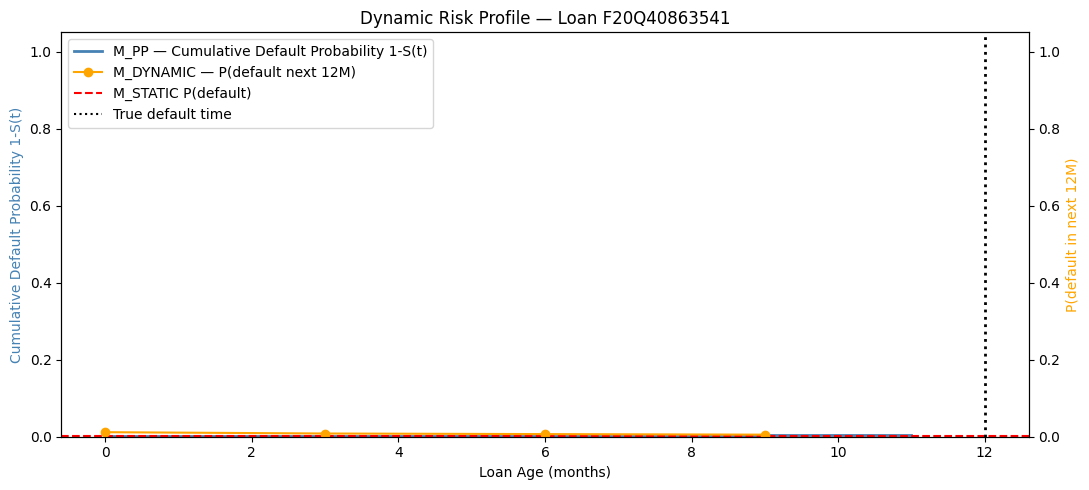

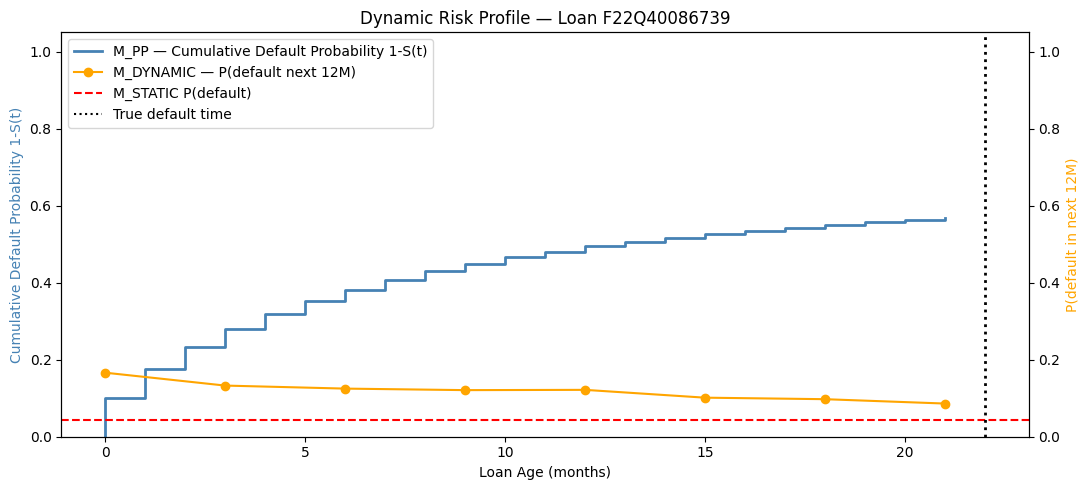

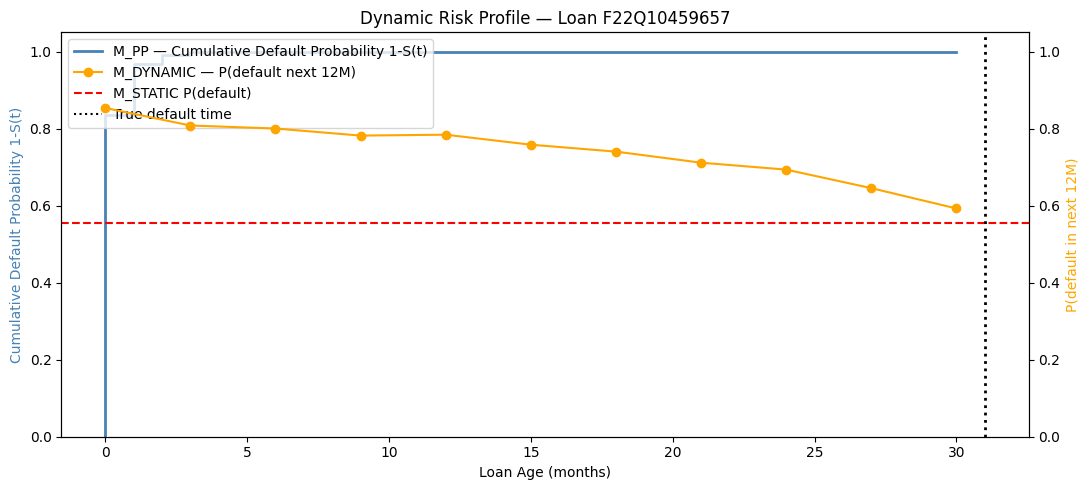

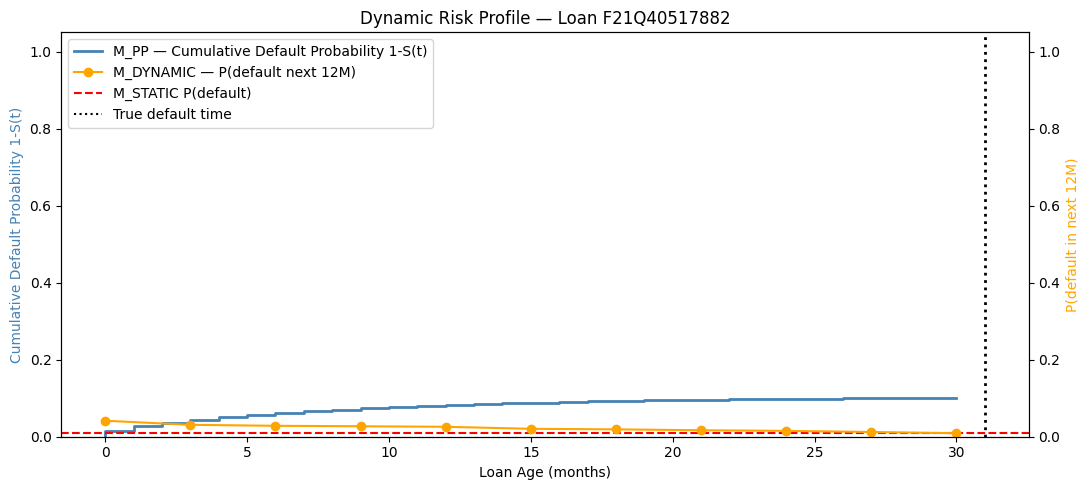

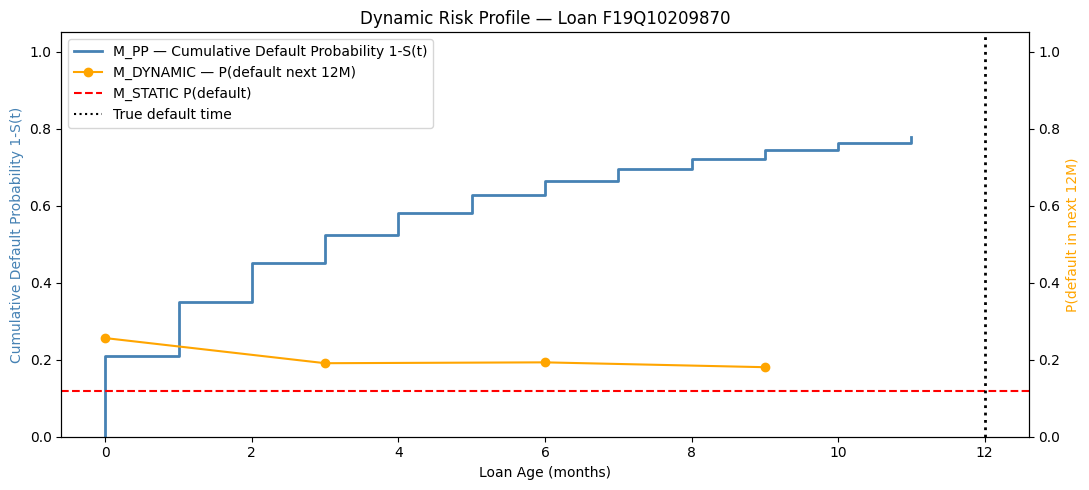

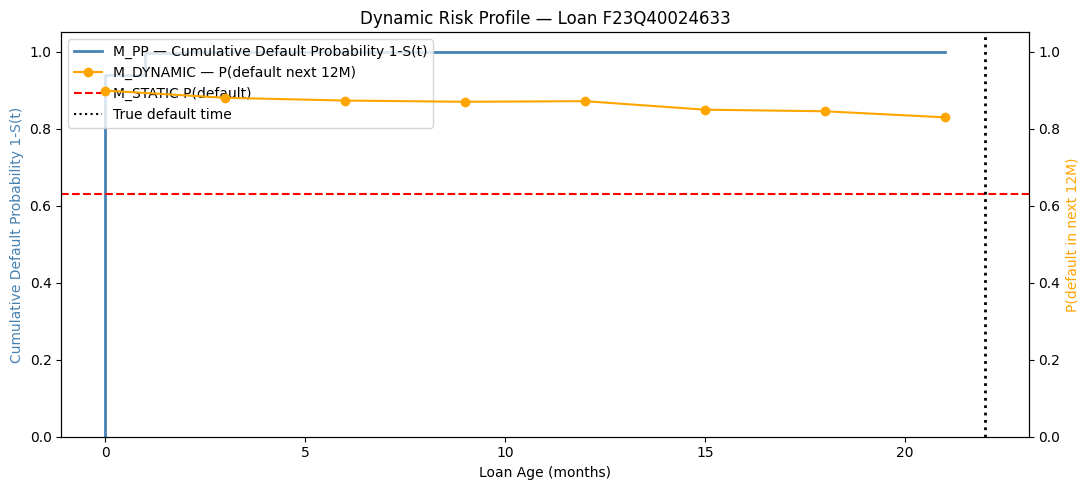

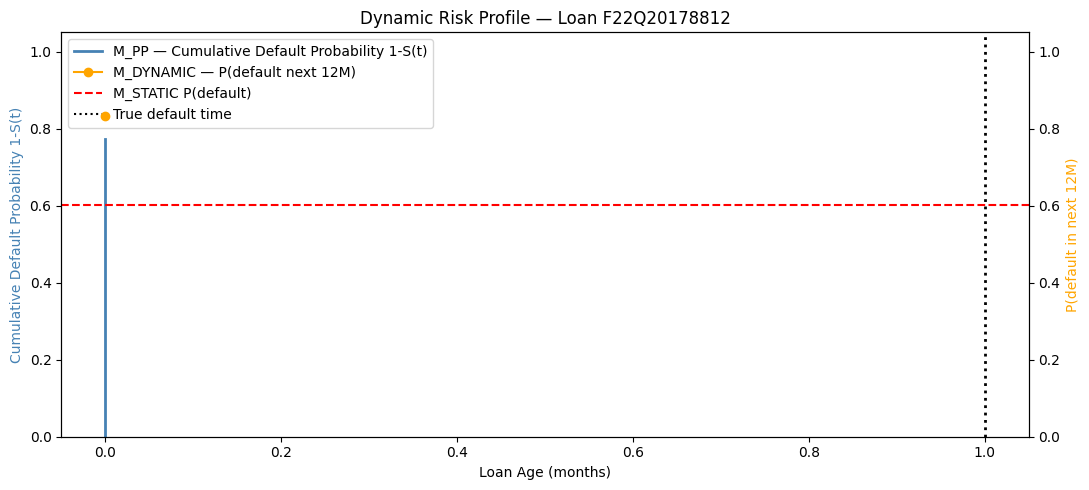

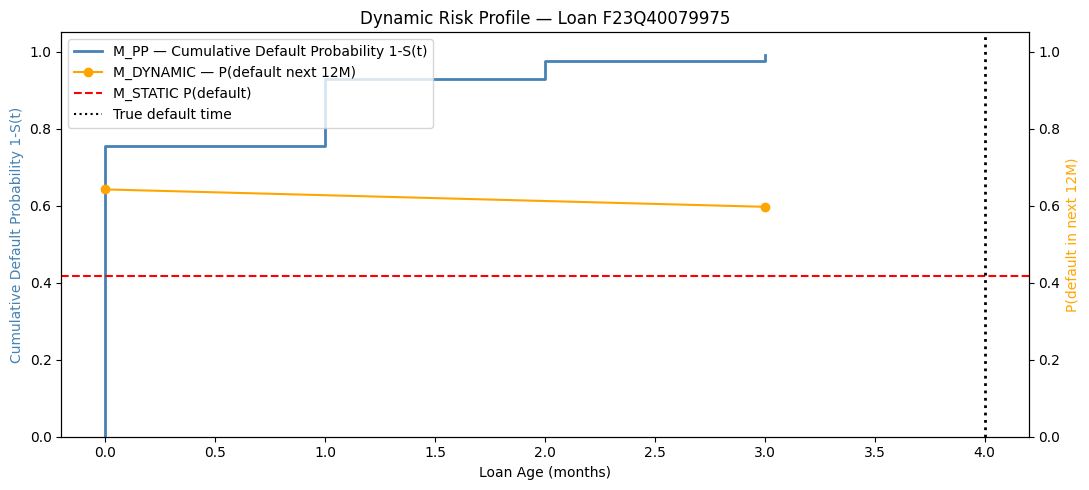

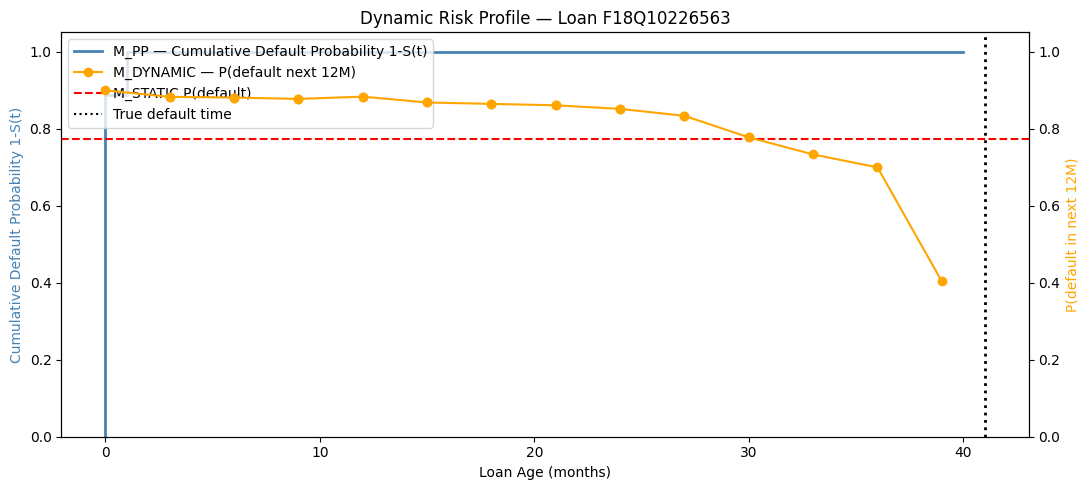

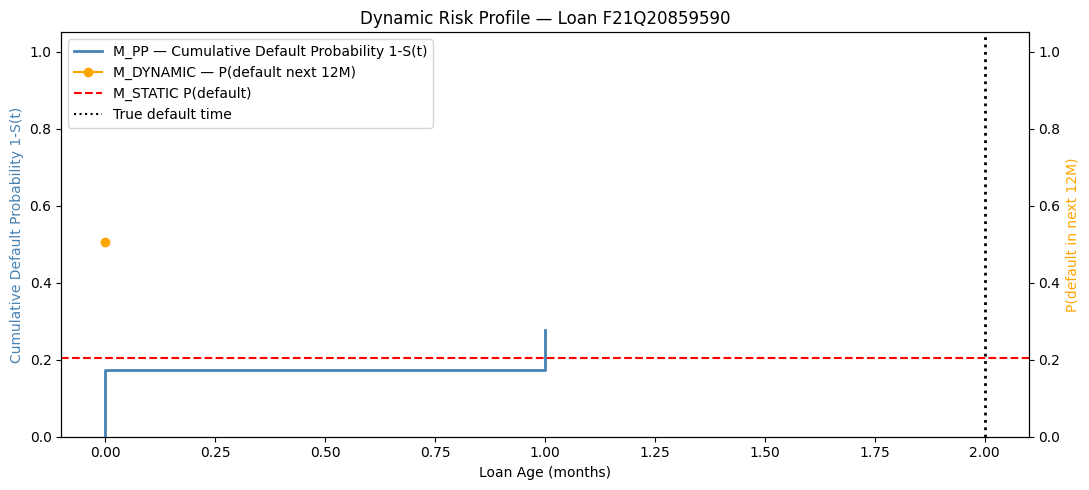


--- LOAN SENZA DEFAULT ---


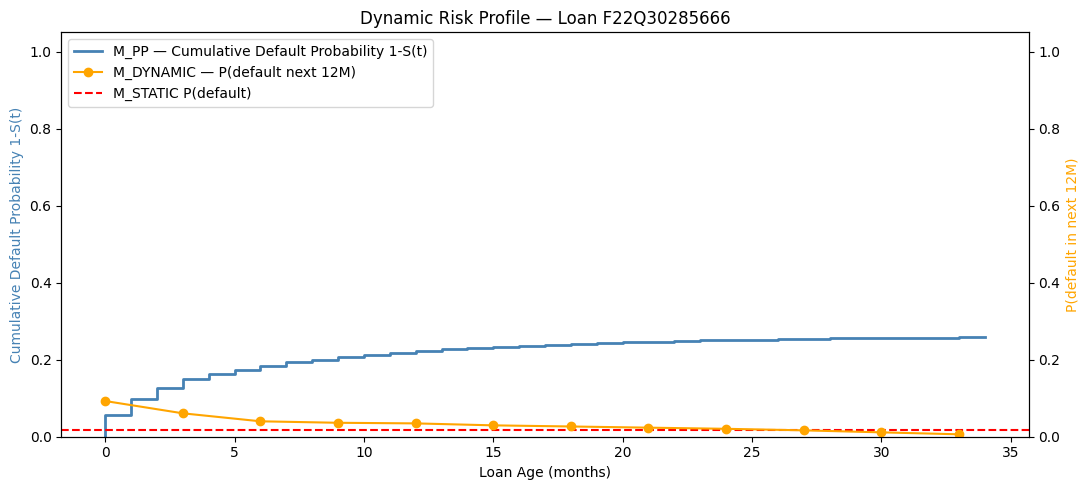

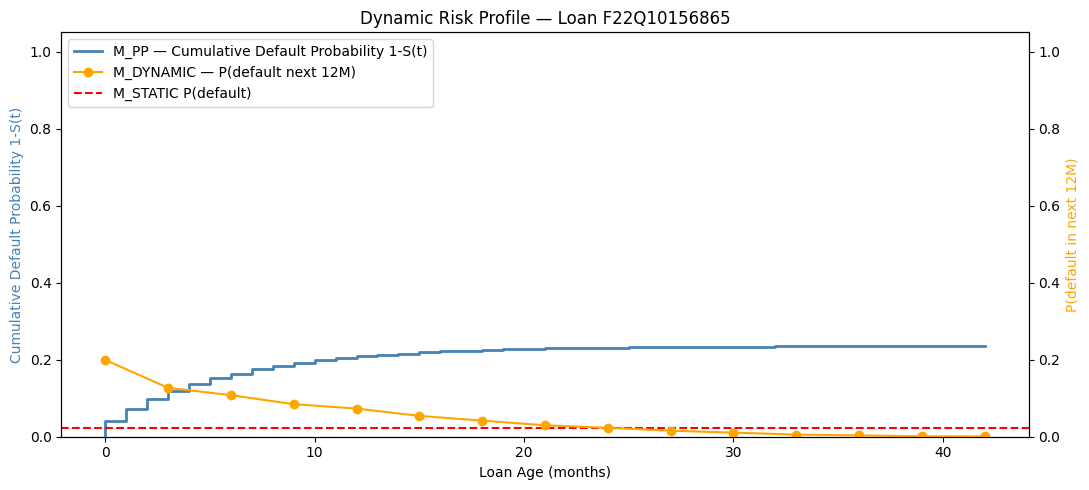

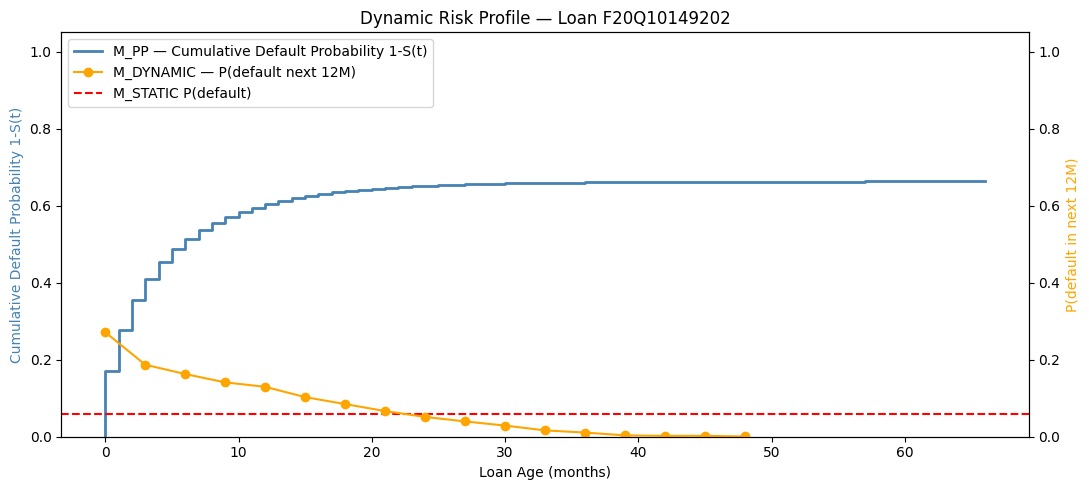

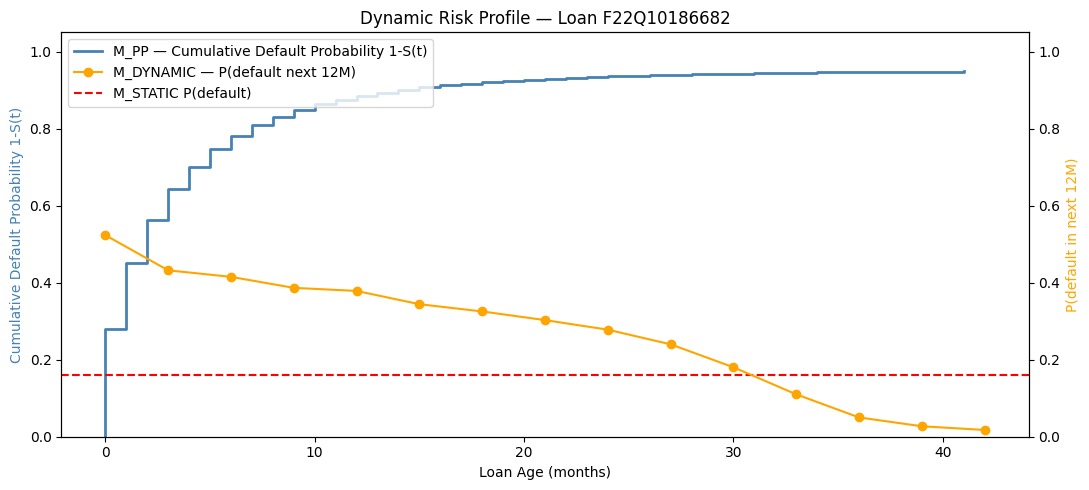

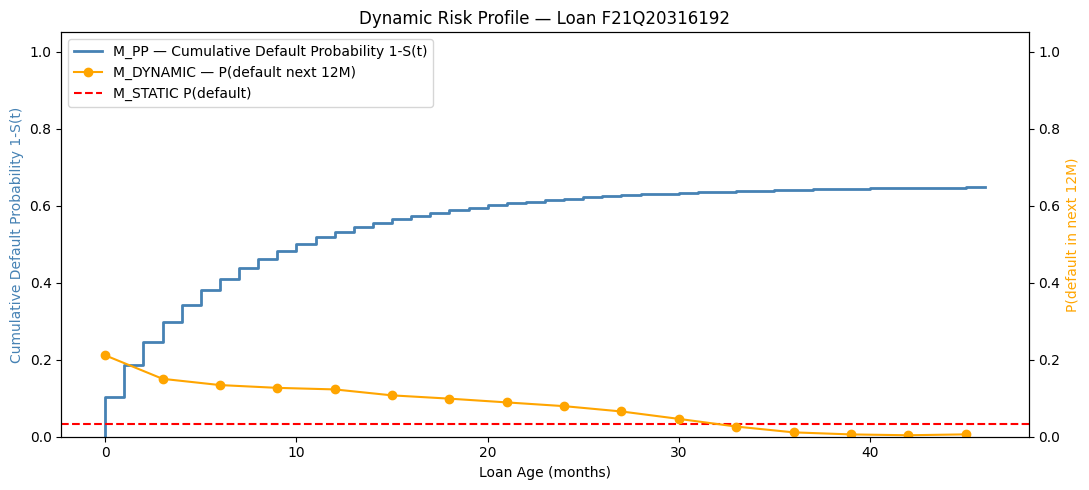

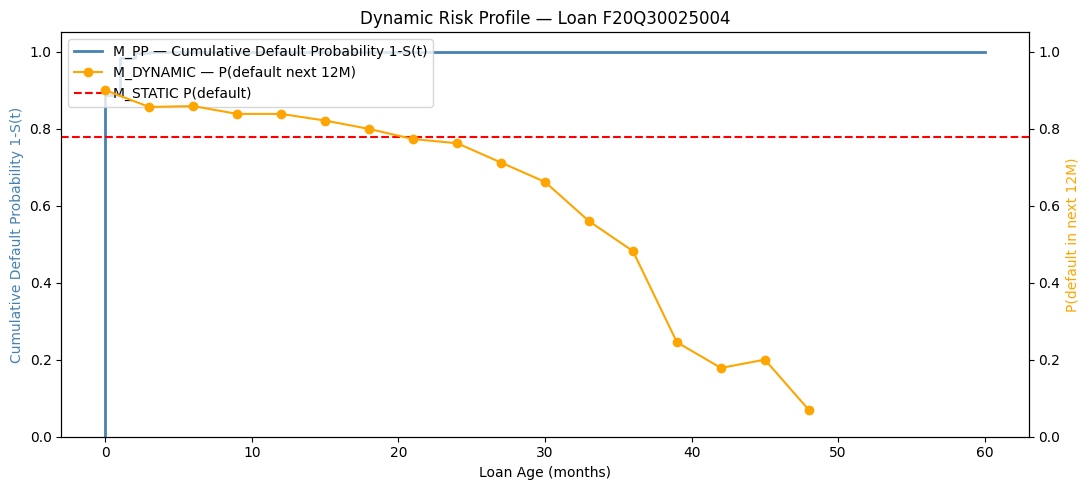

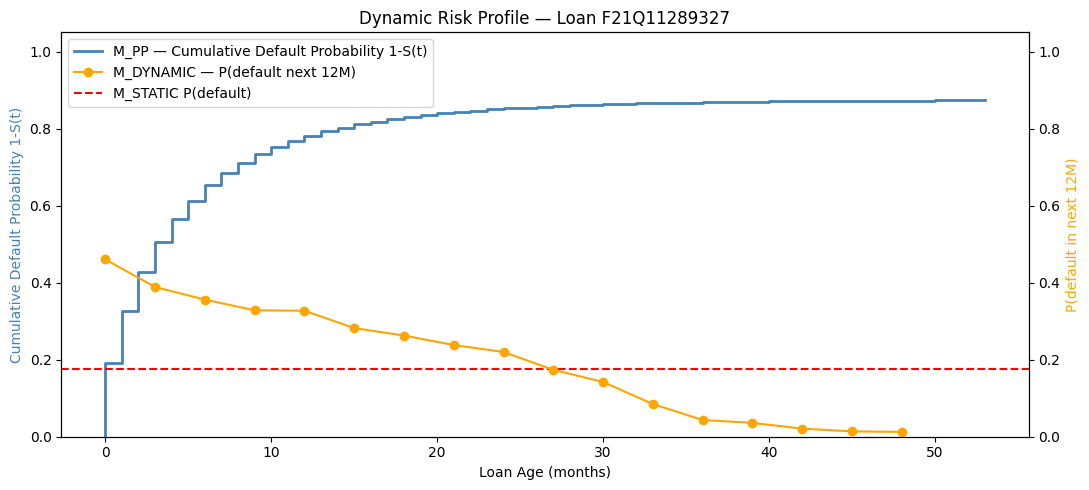

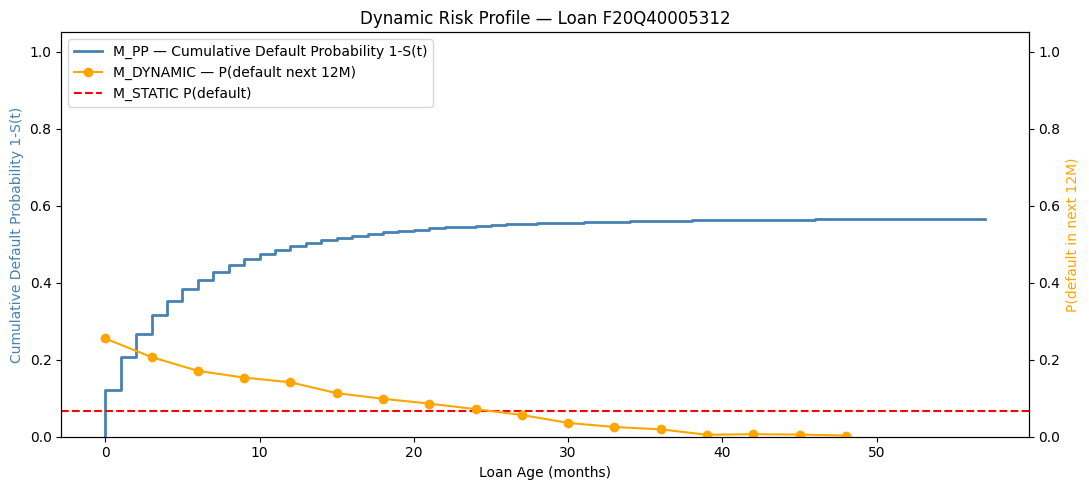

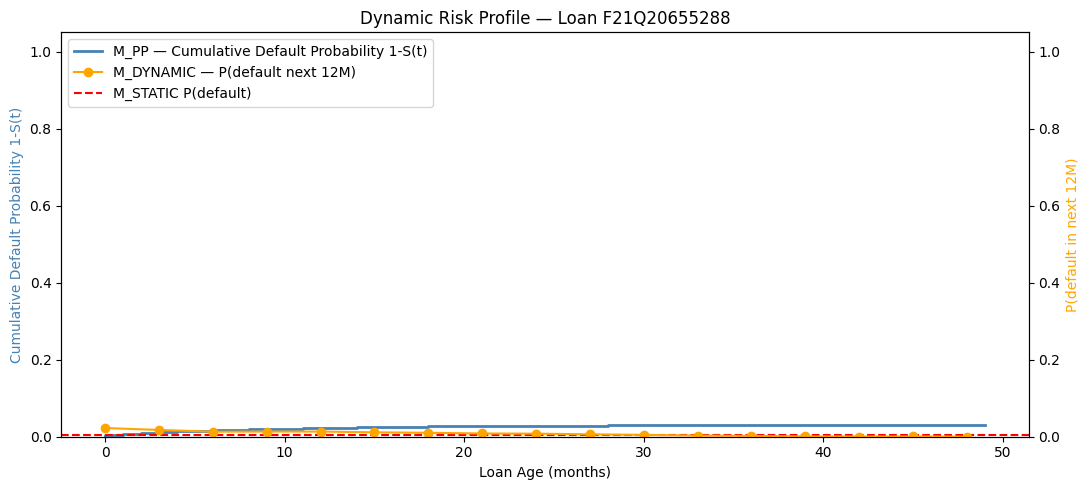

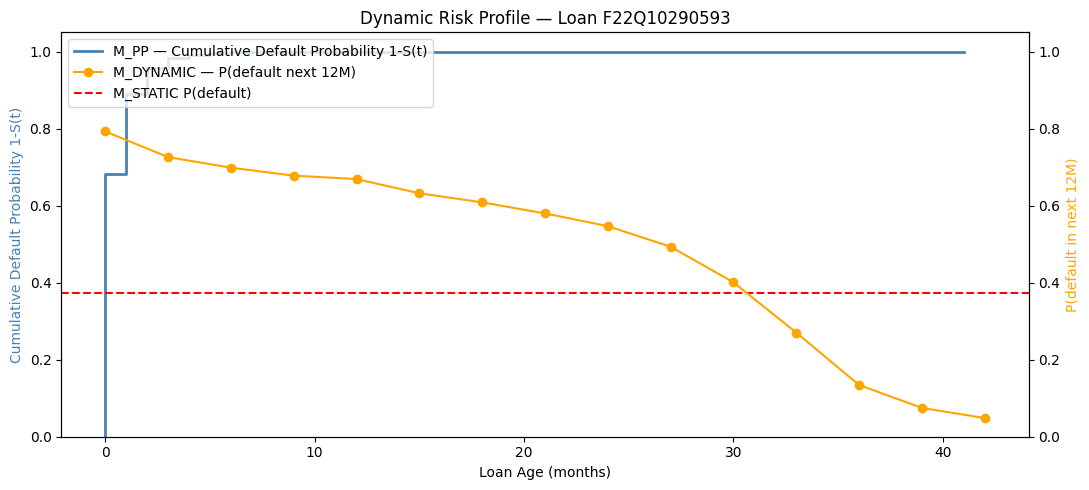

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# ── Helper functions ───────────────────────────────────────────────────────────

def get_first_default_age(loan_id, truth_df):
    row = truth_df[truth_df["loan_sequence_number"] == loan_id]
    if len(row) == 0:
        return None
    val = row["FirstDefaultAge"].iloc[0]
    return None if pd.isna(val) else float(val)

def get_static_prob(loan_id, grp_ids, preds):
    mask = grp_ids == loan_id
    if mask.sum() == 0:
        raise ValueError(f"Loan {loan_id} not found")
    return float(preds[mask][0])

def plot_loan_dynamic_risk_profile(
    loan_id,
    grp_pp, pp_ages, pp_preds,
    grp_dyn, lmk_vals, dyn_preds,
    static_pd,
    truth_df
):
    # ── TRUE DEFAULT ──────────────────────────────────────────────────────────
    true_default_age = get_first_default_age(loan_id, truth_df)

    # ── M_PP (hazard → cumulative PD) ─────────────────────────────────────────
    mask_pp = grp_pp == loan_id
    hz      = pp_preds[mask_pp]
    ages_pp = pp_ages[mask_pp]

    order   = np.argsort(ages_pp)
    hz      = hz[order]
    ages_pp = ages_pp[order]

    times_pp = np.concatenate([[0], ages_pp])
    surv_pp  = np.concatenate([[1.0], np.cumprod(1 - hz)])
    pd_pp    = 1 - surv_pp

    # ── M_DYNAMIC ─────────────────────────────────────────────────────────────
    mask_dyn = grp_dyn == loan_id
    lm       = lmk_vals[mask_dyn]
    p        = dyn_preds[mask_dyn]

    order_d = np.argsort(lm)
    lm      = lm[order_d]
    p       = p[order_d]

    # ── PLOT ──────────────────────────────────────────────────────────────────
    fig, ax1 = plt.subplots(figsize=(11, 5))

    ax1.step(times_pp, pd_pp, where="post", color="steelblue", lw=2)
    ax1.axhline(static_pd, color="red", linestyle="--", lw=1.5)
    ax1.set_xlabel("Loan Age (months)")
    ax1.set_ylabel("Cumulative Default Probability 1-S(t)", color="steelblue")
    ax1.set_ylim(0, 1.05)

    if true_default_age is not None:
        ax1.axvline(true_default_age, color="black", linestyle=":", lw=2)

    ax2 = ax1.twinx()
    ax2.plot(lm, p, "o-", color="orange", lw=1.5, ms=6)
    ax2.set_ylabel("P(default in next 12M)", color="orange")
    ax2.set_ylim(0, 1.05)

    # ── LEGEND ────────────────────────────────────────────────────────────────
    handles = [
        mlines.Line2D([], [], color="steelblue", lw=2,
                      label="M_PP — Cumulative Default Probability 1-S(t)"),
        mlines.Line2D([], [], color="orange", marker="o",
                      label="M_DYNAMIC — P(default next 12M)"),
        mlines.Line2D([], [], color="red", linestyle="--",
                      label="M_STATIC P(default)"),
    ]
    if true_default_age is not None:
        handles.append(
            mlines.Line2D([], [], color="black", linestyle=":",
                          label="True default time")
        )
    ax1.legend(handles=handles, loc="upper left")

    plt.title(f"Dynamic Risk Profile — Loan {loan_id}")
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"risk_profile_{loan_id}.png", dpi=150)
    plt.show()

# ── Prepara truth_df ───────────────────────────────────────────────────────────
truth_df_raw = pd.read_csv(
    DATA_PATH,
    usecols=["loan_sequence_number", "current_loan_delinquency_status", "loan_age"],
    low_memory=False
)
truth_df_raw["Default"] = is_default_vec(truth_df_raw["current_loan_delinquency_status"])
fd_age   = (truth_df_raw[truth_df_raw["Default"] == 1]
            .groupby("loan_sequence_number")["loan_age"].min()
            .rename("FirstDefaultAge"))
truth_df = truth_df_raw.merge(fd_age.reset_index(), on="loan_sequence_number", how="left")
del truth_df_raw

# ── Candidati ─────────────────────────────────────────────────────────────────
static_loans  = set(grp_static)
pp_loans      = set(grp_pp)
dynamic_loans = set(grp_dynamic)
common_loans  = static_loans & pp_loans & dynamic_loans

defaulted_loans         = set(truth_df.dropna(subset=["FirstDefaultAge"])["loan_sequence_number"])
defaulted_candidates    = list(common_loans & defaulted_loans)
non_defaulted_candidates = list(common_loans - defaulted_loans)

print(f"Defaulted disponibili:     {len(defaulted_candidates)}")
print(f"Non-defaulted disponibili: {len(non_defaulted_candidates)}")

# ── Plot ───────────────────────────────────────────────────────────────────────
N = 10

print("\n--- LOAN CON DEFAULT ---")
for loan_id in defaulted_candidates[:N]:
    static_pd = get_static_prob(loan_id, grp_static, static_oof_preds)
    plot_loan_dynamic_risk_profile(
        loan_id  = loan_id,
        grp_pp   = grp_pp,   pp_ages  = pp_ages,   pp_preds  = pp_oof_preds,
        grp_dyn  = grp_dynamic, lmk_vals = lmk_vals, dyn_preds = dynamic_oof_preds,
        static_pd = static_pd, truth_df  = truth_df
    )

print("\n--- LOAN SENZA DEFAULT ---")
for loan_id in non_defaulted_candidates[:N]:
    static_pd = get_static_prob(loan_id, grp_static, static_oof_preds)
    plot_loan_dynamic_risk_profile(
        loan_id  = loan_id,
        grp_pp   = grp_pp,   pp_ages  = pp_ages,   pp_preds  = pp_oof_preds,
        grp_dyn  = grp_dynamic, lmk_vals = lmk_vals, dyn_preds = dynamic_oof_preds,
        static_pd = static_pd, truth_df  = truth_df
    )

#**MLP VANILLA + FAIRNESS + W&B**



Riferimenti rilevanti nel tuo contesto:

Kvamme et al. (2019) — "Time-to-Event Prediction with Neural Networks and Cox Regression" — usa esattamente MLP su PP dataset per survival

Brown & Nair (2018) — applicazione a mortgage default con discrete-time hazard e MLP

Il framework è anche alla base di DeepHit e N-AODE, che sono varianti più complesse ma partono dallo stesso principio


Paper specifici su MLP + discrete-time survival:

Gensheimer & Narasimhan (2019) — "A scalable discrete-time survival model for neural networks". Propone esattamente il tuo approccio: MLP con BCEWithLogitsLoss su dataset PP, trained con SGD. È il paper più vicino alla tua implementazione. PubMed Central
Kvamme et al. (2021) — "Continuous and discrete-time survival prediction with neural networks", Lifetime Data Analysis. Confronta MLP con ReLU, batch normalization e dropout — identico alla tua architettura. PubMed Central

Paper su credit risk + discrete-time survival + neural network:

Ryu et al. (2024) — "Discrete-Time Survival Models with Neural Networks for Age–Period–Cohort Analysis of Credit Risk", MDPI Risks. È il paper più rilevante perché applica esattamente il tuo framework a mortgage/credit default, con decomposizione APC del rischio. MDPI


MODELLO DEFINITO IN: Time-to-Event Prediction with Neural Networks and Cox Regression

ALTRE SCELTE:
1. Bias InitializationThe output layer bias is initialized to the log-odds of the empirical event rate, b0=log⁡(yˉ/(1−yˉ))b_0 = \log(\bar{y} / (1 - \bar{y}))
b0​=log(yˉ​/(1−yˉ​)), following Goodfellow et al. (2016). This ensures that the model's initial predictions match the marginal prevalence, accelerating convergence on severely imbalanced datasets.

2. Weighted Loss with Capped Positive Weight
To address class imbalance, we use BCEWithLogitsLoss with a positive class weight w+=min⁡(n−/n+, 15)w^+ = \min(n^- / n^+,\ 15)
w+=min(n−/n+, 15). The cap at 15× prevents training instability caused by extreme gradient magnitudes, which would otherwise arise from the raw imbalance ratio of approximately 120× in the person-period dataset.

3. Gradient ClippingGradients are clipped to a maximum ℓ2\ell_2
ℓ2​ norm of 5.0 at each training step (Pascanu et al., 2013), providing an additional safeguard against exploding gradients in the presence of large positive weights.

4. Group-based Cross-Validation
We use GroupKFold with K=5K=5
K=5 folds, grouping by loan_sequence_number. This ensures that all person-period observations belonging to the same loan are assigned to the same fold, preventing data leakage and providing an unbiased estimate of out-of-sample performance.

5. Adaptive Learning Rate
The learning rate is reduced by a factor of 0.5 when the training loss plateaus for 20 consecutive epochs (ReduceLROnPlateau), allowing fine-grained convergence without manual tuning.

Opzione A — LR (Cell 2)

Modello interpretabile, coefficienti leggibili
Feature ingegnerizzate con spline (credit_score, LTV, DTI, upb_ratio)
Pro: interpretabilità massima, giustificabile teoricamente
Contro: meno flessibile, potrebbe avere AUC leggermente inferiore

Opzione B — MLP (Cell 6)

Rete neurale 64→32, più flessibile
Feature più semplici (bd_pct + trend)
Pro: cattura non-linearità, ha già il fairness penalty placeholder pronto
Contro: meno interpretabile, black box parziale



Using device: cuda


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: alessia-ciccaglione02 (ADSP-HYPE) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Loading data...
  Righe: 3,792,126  |  Loan unici: 99,970

Computing BD_pct...
  bd_pct: NaN=34,464  mean=-0.0265  std=0.1095
  Loan totali: 99,970  |  Defaulters: 9,997 (10.0%)

Building PERSON-PERIOD dataset...
  Righe: 3,443,703 | Default: 9991 (0.29%)

[CHECK] X_pp: shape=(3443703, 20)  NaN=0  Inf=0
  label: n=3443703  pos=9991  prev=0.0029

Building STATIC dataset (t=0)...
  Righe: 99,970 | Default: 4296 (4.30%)

[CHECK] X_static: shape=(99970, 12)  NaN=0  Inf=0
  label: n=99970  pos=4296  prev=0.0430

Building DYNAMIC dataset (landmarks + TVC)...
  Righe: 1,135,986 | Default: 32025 (2.82%)

[CHECK] X_dynamic: shape=(1135986, 33)  NaN=0  Inf=0
  label: n=1135986  pos=32025  prev=0.0282

Training STATIC model...


/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:1694: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  current = float(metrics)


  [static] pred_mean_train=0.3086  pred_mean_test=0.3106  prev_train=0.0426  prev_test=0.0447
  Fold 1 — AUC: 0.6984
  [static] pred_mean_train=0.3036  pred_mean_test=0.3029  prev_train=0.0431  prev_test=0.0427
  Fold 2 — AUC: 0.6740
  [static] pred_mean_train=0.3334  pred_mean_test=0.3332  prev_train=0.0432  prev_test=0.0422
  Fold 3 — AUC: 0.6866
  [static] pred_mean_train=0.3240  pred_mean_test=0.3236  prev_train=0.0431  prev_test=0.0427
  Fold 4 — AUC: 0.6829
  [static] pred_mean_train=0.3206  pred_mean_test=0.3199  prev_train=0.0431  prev_test=0.0427
  Fold 5 — AUC: 0.6685

Training DYNAMIC model...
  [dynamic] pred_mean_train=0.2037  pred_mean_test=0.2023  prev_train=0.0282  prev_test=0.0283
  Fold 1 — AUC: 0.7388
  [dynamic] pred_mean_train=0.2297  pred_mean_test=0.2314  prev_train=0.0283  prev_test=0.0277
  Fold 2 — AUC: 0.7427
  [dynamic] pred_mean_train=0.2218  pred_mean_test=0.2229  prev_train=0.0280  prev_test=0.0291
  Fold 3 — AUC: 0.7411
  [dynamic] pred_mean_train=0.2245

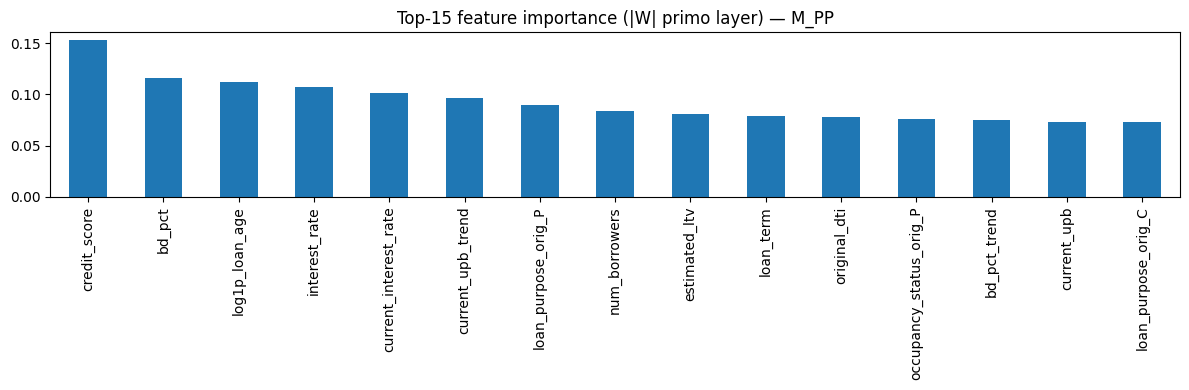


[CHECK] Calibrazione OOF:
  STATIC: real=0.0430  pred=0.3180  ratio=7.40x
  DYNAMIC: real=0.0282  pred=0.2224  ratio=7.89x
  PP: real=0.0029  pred=0.0312  ratio=10.77x


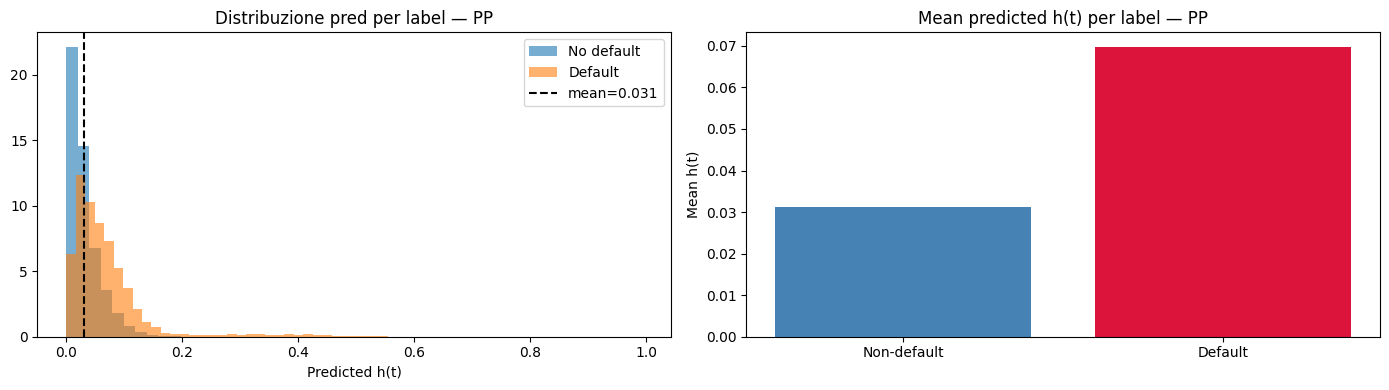


[CHECK] Separazione score PP:
  Defaulters:     mean=0.0698
  Non-defaulters: mean=0.0311
  Differenza:     0.0386

=== RISULTATI FINALI ===
    Model  AUC_Mean   AUC_SD  Brier_Mean  Brier_SD  F1_Mean    F1_SD  Time_Mean_sec  Time_SD_sec
 M_STATIC  0.682083 0.010376    0.130697  0.005743 0.150920 0.007333       3.873525     3.246470
M_DYNAMIC  0.742802 0.004587    0.079659  0.004413 0.154314 0.007064      14.907388     0.047789
     M_PP  0.739729 0.006529    0.004445  0.000109 0.020239 0.000463      45.273662     0.357945

=== DINAMICO — AUC PER LANDMARK ===
 Landmark  AUC_Mean  Brier_Mean  F1_Mean
        0  0.696747    0.148045 0.156117
        3  0.713949    0.118438 0.156413
        6  0.714895    0.112653 0.150388
        9  0.716002    0.101032 0.142477
       12  0.709133    0.102878 0.131366
       15  0.731364    0.090514 0.144105
       18  0.742522    0.083830 0.138154
       21  0.745252    0.077826 0.141361
       24  0.751686    0.068713 0.151486
       27  0.749467    

dynamic/AGE/auc_gap,▁
dynamic/AGE/dp_gap,▁
dynamic/AGE/fpr_gap,▁
dynamic/AGE/independence,▁
dynamic/AGE/mean_score_gap,▁
dynamic/AGE/ppv_gap,▁
dynamic/AGE/separation,▁
dynamic/AGE/sufficiency,▁
dynamic/AGE/tpr_gap,▁
dynamic/RACE/auc_gap,▁
+116,...


In [4]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings, time, gc
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import roc_auc_score, brier_score_loss, f1_score, precision_recall_curve
from sklearn.model_selection import GroupKFold
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim


np.random.seed(42)
torch.manual_seed(42)
warnings.filterwarnings("ignore", category=FutureWarning)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

filepath = os.path.join(output_path, 'panel_all_years_sampled.csv')
DATA_PATH      = filepath
OUT_DIR        = Path("/content/out")
OUT_DIR.mkdir(parents=True, exist_ok=True)

HORIZON_MONTHS = 12
LANDMARKS      = [0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 36, 39, 42, 45, 48]


import wandb
FAIR_ALPHA = 1000
FAIR_ATTR  = "RACE"


wandb.init(
    entity="alessia-ciccaglione02-",
    # Set the wandb project where this run will be logged.
    project="ThesisFairness",
    name    = f"race_alpha0",
    config  = {
        "fair_attr":      FAIR_ATTR,
        "fair_alpha":     FAIR_ALPHA,
        "apply_fair":     ["static"],
        "lr":             1e-3,
        "n_epochs":       300,
        "dropout":        0.3,
        "hidden1":        64,
        "hidden2":        32,
        "pos_weight_cap": 15.0,
        "n_folds":        5,
    }
)

# ── Helpers ────────────────────────────────────────────────────────────────────
import torch
from torch import nn
from torch.nn import functional as F


class ConstraintLoss(nn.Module):
    def __init__(self, n_class=2, alpha=1, p_norm=2):
        super(ConstraintLoss, self).__init__()
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.alpha = alpha
        self.p_norm = p_norm
        self.n_class = n_class
        self.n_constraints = 2
        self.dim_condition = self.n_class + 1
        self.M = torch.zeros((self.n_constraints, self.dim_condition))
        self.c = torch.zeros(self.n_constraints)

    def mu_f(self, X=None, y=None, sensitive=None):
        return torch.zeros(self.n_constraints)

    def forward(self, X, out, sensitive, y=None):
        sensitive = sensitive.view(out.shape)
        if isinstance(y, torch.Tensor):
            y = y.view(out.shape)
        out = torch.sigmoid(out)
        mu = self.mu_f(X=X, out=out, sensitive=sensitive, y=y)
        gap_constraint = F.relu(
            torch.mv(self.M.to(self.device), mu.to(self.device)) - self.c.to(self.device)
        )
        if self.p_norm == 2:
            cons = self.alpha * torch.dot(gap_constraint, gap_constraint)
        else:
            cons = self.alpha * torch.dot(gap_constraint.detach(), gap_constraint)
        return cons

class EqualiedOddsLoss(ConstraintLoss):
    def __init__(self, sensitive_classes=[0, 1], alpha=1, p_norm=2):
        """loss of demograpfhic parity

        Args:
            sensitive_classes (list, optional): list of unique values of sensitive attribute. Defaults to [0, 1].
            alpha (int, optional): [description]. Defaults to 1.
            p_norm (int, optional): [description]. Defaults to 2.
        """
        self.sensitive_classes = sensitive_classes
        self.y_classes = [0, 1]
        self.n_class = len(sensitive_classes)
        self.n_y_class = len(self.y_classes)
        super(EqualiedOddsLoss, self).__init__(n_class=self.n_class, alpha=alpha, p_norm=p_norm)
        # K:  number of constraint : (|A| x |Y| x {+, -})
        self.n_constraints = self.n_class * self.n_y_class * 2
        # J : dim of conditions  : ((|A|+1) x |Y|)
        self.dim_condition = self.n_y_class * (self.n_class + 1)
        self.M = torch.zeros((self.n_constraints, self.dim_condition))
        # make M (K * J): (|A| x |Y| x {+, -})  *   (|A|+1) x |Y|) )
        self.c = torch.zeros(self.n_constraints)
        element_K_A = self.sensitive_classes + [None]
        for i_a, a_0 in enumerate(self.sensitive_classes):
            for i_y, y_0 in enumerate(self.y_classes):
                for i_s, s in enumerate([-1, 1]):
                    for j_y, y_1 in enumerate(self.y_classes):
                        for j_a, a_1 in enumerate(element_K_A):
                            i = i_a * (2 * self.n_y_class) + i_y * 2 + i_s
                            j = j_y + self.n_y_class * j_a
                            self.M[i, j] = self.__element_M(a_0, a_1, y_1, y_1, s)

    def __element_M(self, a0, a1, y0, y1, s):
        if a0 is None or a1 is None:
            x = y0 == y1
            return -1 * s * x
        else:
            x = (a0 == a1) & (y0 == y1)
            return s * float(x)

    def mu_f(self, X, out, sensitive, y):
        expected_values_list = []
        for u in self.sensitive_classes:
            for v in self.y_classes:
                idx_true = (y == v) * (sensitive == u)  # torch.bool
                expected_values_list.append(out[idx_true].mean())
        # sensitive is star
        for v in self.y_classes:
            idx_true = y == v
            expected_values_list.append(out[idx_true].mean())
        return torch.stack(expected_values_list)

    def forward(self, X, out, sensitive, y):
        return super(EqualiedOddsLoss, self).forward(X, out, sensitive, y=y)

def is_default_vec(s):
    num = pd.to_numeric(s, errors="coerce")
    return (num.notna() & (num != 0)).astype(np.int8)


def find_best_threshold(y_true, p, max_th_quantile=0.90):
    p = np.clip(p, 0, 1)
    prec, rec, thresholds = precision_recall_curve(y_true, p)
    max_th    = np.quantile(p, max_th_quantile)
    f1_scores = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-8)
    f1_scores[thresholds > max_th] = 0
    return thresholds[np.argmax(f1_scores)] if len(thresholds) > 0 else 0.5

def metrics_all(y_true, p, threshold=0.5):
    p   = np.clip(p, 0, 1)
    auc = roc_auc_score(y_true, p) if len(np.unique(y_true)) > 1 else np.nan
    return dict(
        AUC   = auc,
        Brier = brier_score_loss(y_true, p),
        F1    = f1_score(y_true, (p >= threshold), zero_division=0),
        Th    = threshold,
    )

def agg_mean_sd(list_of_dicts):
    out = {}
    for k in list_of_dicts[0].keys():
        vals = [d[k] for d in list_of_dicts]
        out[f"{k}_Mean"] = float(np.nanmean(vals))
        out[f"{k}_SD"]   = float(np.nanstd(vals))
    return out

def check_array(name, arr, y=None):
    print(f"\n[CHECK] {name}: shape={arr.shape}  NaN={np.isnan(arr).sum()}  Inf={np.isinf(arr).sum()}")
    if y is not None:
        print(f"  label: n={len(y)}  pos={y.sum()}  prev={y.mean():.4f}")

def scheduled_balance(orig_upb, r, N, a):
    """
    Saldo teorico al mese a secondo il piano di ammortamento originale.
    r = tasso annuo (percentuale o decimale), N = mesi totali, a = mese corrente.
    """
    try:
        orig_upb = float(orig_upb); r = float(r)
        N = int(float(N));          a = float(a)
    except:
        return np.nan
    if any(np.isnan(x) for x in [orig_upb, r, N, a]):
        return np.nan
    if r > 1:
        r /= 100.0
    if r < 0 or N <= 0 or N > 1000:
        return np.nan
    rm = r / 12.0
    if abs(rm) < 1e-10:
        return max(0.0, orig_upb - (orig_upb / N) * a)
    a = np.clip(a, 0, N)
    try:
        num = (1 + rm)**N - (1 + rm)**a
        den = (1 + rm)**N - 1
        return max(0.0, orig_upb * num / den) if den != 0 else np.nan
    except OverflowError:
        return np.nan

def compute_bd_pct(cur_upb, sched):
    """
    Balance Deviation %: (saldo_corrente - saldo_teorico) / saldo_teorico.
    Positivo = mutuatario in ritardo rispetto al piano (segnale di rischio).
    Negativo = ha pagato più del previsto.
    """
    if pd.isna(cur_upb) or pd.isna(sched) or sched <= 1:
        return np.nan
    return (cur_upb - sched) / sched

# ── MLP ────────────────────────────────────────────────────────────────────────
class MLP(nn.Module):
    def __init__(self, input_dim, hidden1=64, hidden2=32, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.BatchNorm1d(hidden1),
            nn.Dropout(dropout),

            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.BatchNorm1d(hidden2),
            nn.Dropout(dropout),

            nn.Linear(hidden2, 1),
        )

    def forward(self, x):
        return self.net(x).view(-1)

    def init_bias(self, prev):
        bias_val = float(np.log(prev / (1 - prev + 1e-9)))
        with torch.no_grad():
            self.net[-1].bias.fill_(bias_val)


# ── Training loop ──────────────────────────────────────────────────────────────
def train_mlp(
    Xtr, ytr, Xte, yte,
    sensitive_tr=None,
    model_name="",
    hidden1=64, hidden2=32, dropout=0.3,
    lr=1e-3, weight_decay=1e-4,
    n_epochs=300, pos_weight_cap=15.0,
):
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


    scaler = StandardScaler()
    Xtr_s  = scaler.fit_transform(Xtr).astype(np.float32)
    Xte_s  = scaler.transform(Xte).astype(np.float32)
    Xtr_s  = np.nan_to_num(Xtr_s, nan=0.0, posinf=5.0, neginf=-5.0)
    Xte_s  = np.nan_to_num(Xte_s, nan=0.0, posinf=5.0, neginf=-5.0)

    X_train = torch.tensor(Xtr_s, device=DEVICE)
    y_train = torch.tensor(ytr.astype(np.float32), device=DEVICE)
    X_test  = torch.tensor(Xte_s, device=DEVICE)
    sens_train = (
    torch.tensor(sensitive_tr.astype(np.float32), device=DEVICE)
    if sensitive_tr is not None else None
    )

    n_pos = (ytr == 1).sum(); n_neg = (ytr == 0).sum()
    pw    = float(np.clip(n_neg / max(n_pos, 1), 1.0, pos_weight_cap))
    pos_w = torch.tensor([pw], dtype=torch.float32, device=DEVICE)
    model     = MLP(X_train.shape[1], hidden1, hidden2, dropout).to(DEVICE)
    model.init_bias(n_pos / (n_pos + n_neg))
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_w)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=20, factor=0.5)
    dp_loss = EqualiedOddsLoss(sensitive_classes=[0, 1], alpha=FAIR_ALPHA)


    model.train()
    for epoch in range(n_epochs):
        optimizer.zero_grad()
        logits   = model(X_train)
        bce_loss = criterion(logits, y_train)
        loss = bce_loss
        if model_name == "static" and sens_train is not None:
            loss += dp_loss(X_train, logits, sens_train, y_train)


        if not torch.isfinite(loss):
            print(f"  [WARN] Loss non finita all'epoch {epoch}"); break

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        scheduler.step(loss)

    model.eval()
    with torch.no_grad():
        p_te = torch.sigmoid(model(X_test)).cpu().numpy()
        p_tr = torch.sigmoid(model(X_train)).cpu().numpy()

    print(f"  [{model_name}] pred_mean_train={p_tr.mean():.4f}  pred_mean_test={p_te.mean():.4f}  "
          f"prev_train={ytr.mean():.4f}  prev_test={yte.mean():.4f}")
    return p_te, p_tr, model, scaler

# ── Load data ──────────────────────────────────────────────────────────────────
print("Loading data...")
df = pd.read_csv(DATA_PATH, usecols=[
    "loan_sequence_number", "loan_age", "loan_term",
    "current_upb", "current_interest_rate", "estimated_ltv",
    "current_loan_delinquency_status", "loan_amount",
    "original_ltv", "original_dti", "credit_score",
    "interest_rate", "num_borrowers",
    "occupancy_status_orig", "loan_purpose_orig",
    "applicant_sex", "derived_race", "applicant_age",
], low_memory=False)

print(f"  Righe: {len(df):,}  |  Loan unici: {df['loan_sequence_number'].nunique():,}")
# ── BD_pct: balance deviation vs schedule teorico ──────────────────────────────
print("\nComputing BD_pct...")
df["loan_amount"]      = pd.to_numeric(df["loan_amount"],      errors="coerce").astype("float32")
df["interest_rate"]    = pd.to_numeric(df["interest_rate"],    errors="coerce").astype("float32")
df["loan_term"]        = pd.to_numeric(df["loan_term"],        errors="coerce").astype("float32")
df["loan_age"]         = pd.to_numeric(df["loan_age"],         errors="coerce").astype("float32")
df["current_upb"]      = pd.to_numeric(df["current_upb"],      errors="coerce").astype("float32")

df["b_sched"] = df.apply(
    lambda r: scheduled_balance(r["loan_amount"], r["interest_rate"],
                                r["loan_term"],   r["loan_age"]), axis=1
).astype("float32")

df["bd_pct"] = df.apply(
    lambda r: compute_bd_pct(r["current_upb"], r["b_sched"]), axis=1
).astype("float32")

df["bd_pct"] = df["bd_pct"].replace([np.inf, -np.inf], np.nan).clip(-2, 2)
print(f"  bd_pct: NaN={df['bd_pct'].isna().sum():,}  "
      f"mean={df['bd_pct'].mean():.4f}  std={df['bd_pct'].std():.4f}")



# Trend ultimi 3 mesi — segnale di deterioramento progressivo
# Trend ultimi 2 mesi
df = df.sort_values(["loan_sequence_number", "loan_age"])
for col in ["bd_pct", "estimated_ltv", "current_upb"]:
    df[f"{col}_trend"] = (
        df.groupby("loan_sequence_number")[col].transform(
            lambda x: x - x.shift(2)
        )
    ).clip(-2, 2).fillna(0)

TREND_COLS = ["bd_pct_trend", "estimated_ltv_trend", "current_upb_trend"]


# ── Feature columns ────────────────────────────────────────────────────────────
TVC_COLS    = ["current_upb", "current_interest_rate", "estimated_ltv","bd_pct"]
STATIC_COLS = ["credit_score", "original_dti", "original_ltv",
               "interest_rate", "loan_term", "num_borrowers"]
CAT_COLS    = ["occupancy_status_orig", "loan_purpose_orig"]


for c in STATIC_COLS + TVC_COLS + ["loan_age", "loan_amount"]:
    df[c] = pd.to_numeric(df[c], errors="coerce").astype("float32")
df["occupancy_status_orig"] = df["occupancy_status_orig"].astype("category")
df["loan_purpose_orig"]     = df["loan_purpose_orig"].astype("category")

# ── Demografiche ───────────────────────────────────────────────────────────────
df["sex_bin"]  = df["applicant_sex"].map({1: 0, 2: 1})

def race_map(x):
    if not isinstance(x, str): return np.nan
    x = x.strip().lower()
    if x in ["white", "asian"]: return 0
    if x in ["black or african american", "american indian or alaska native",
              "native hawaiian or other pacific islander", "2 or more races", "other"]: return 1
    return np.nan
df["race_bin"] = df["derived_race"].apply(race_map)
df["age_bin"]  = df["applicant_age"].map(
    {"<25":1,"25-34":0,"35-44":0,"45-54":0,"55-64":0,"65-74":0,">74":0})

for col, name in [("sex_bin","sex_bin_loan"),("race_bin","race_bin_loan"),("age_bin","age_bin_loan")]:
    per_loan = df.groupby("loan_sequence_number")[col].first().rename(name)
    df = df.merge(per_loan, on="loan_sequence_number", how="left")

# ── Default flag ───────────────────────────────────────────────────────────────
df["Default"] = is_default_vec(df["current_loan_delinquency_status"])
df.drop(columns=["current_loan_delinquency_status"], inplace=True)

fd_age = (df[df["Default"] == 1]
          .groupby("loan_sequence_number")["loan_age"].min()
          .rename("FirstDefaultAge"))
df = df.merge(fd_age, on="loan_sequence_number", how="left")
df.drop(columns=["Default"], inplace=True)

n_loans      = df["loan_sequence_number"].nunique()
n_defaulters = df.groupby("loan_sequence_number")["FirstDefaultAge"].first().notna().sum()
print(f"  Loan totali: {n_loans:,}  |  Defaulters: {n_defaulters:,} ({n_defaulters/n_loans:.1%})")
df = df.sort_values(["loan_sequence_number", "loan_age"])

# ── Person-period dataset ──────────────────────────────────────────────────────
print("\nBuilding PERSON-PERIOD dataset...")
df_pp = df.sort_values(["loan_sequence_number", "loan_age"]).copy()
df_pp["is_default_now"] = (
    df_pp["FirstDefaultAge"].notna() &
    (df_pp["loan_age"] == df_pp["FirstDefaultAge"])
).astype(np.int8)

df_pp["default_next"] = (
    df_pp.groupby("loan_sequence_number")["is_default_now"]
    .shift(-1).fillna(0).astype(np.int8)
)

last_mask = df_pp["loan_age"] == df_pp.groupby("loan_sequence_number")["loan_age"].transform("max")
df_pp = df_pp[~last_mask]
df_pp = df_pp[df_pp["FirstDefaultAge"].isna() | (df_pp["loan_age"] < df_pp["FirstDefaultAge"])]
pp_df = df_pp.copy()
del df_pp; gc.collect()
print(f"  Righe: {len(pp_df):,} | Default: {pp_df['default_next'].sum()} ({pp_df['default_next'].mean():.2%})")

enc_cat_pp = OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=np.float32)
cats_pp    = enc_cat_pp.fit_transform(pp_df[CAT_COLS])
medians_pp = pp_df[STATIC_COLS + TVC_COLS].median()
log_age_pp = np.log1p(pp_df["loan_age"].to_numpy(dtype=np.float32)).reshape(-1, 1)

X_pp = np.hstack([
    pp_df[STATIC_COLS].fillna(medians_pp[STATIC_COLS]).to_numpy(dtype=np.float32),
    pp_df[TVC_COLS].fillna(medians_pp[TVC_COLS]).to_numpy(dtype=np.float32),
    pp_df[TREND_COLS].fillna(0).to_numpy(dtype=np.float32),
    cats_pp,
    log_age_pp,
])
y_pp    = pp_df["default_next"].to_numpy(dtype=np.int8)
grp_pp  = pp_df["loan_sequence_number"].to_numpy()
pp_ages = pp_df["loan_age"].to_numpy()
sex_pp  = pp_df["sex_bin_loan"].to_numpy()
race_pp = pp_df["race_bin_loan"].to_numpy()
age_pp  = pp_df["age_bin_loan"].to_numpy()
nb_pp   = pp_df["num_borrowers"].to_numpy()
check_array("X_pp", X_pp, y_pp)
del pp_df, cats_pp; gc.collect()

# ── Static dataset ─────────────────────────────────────────────────────────────
print("\nBuilding STATIC dataset (t=0)...")
static_df = df.sort_values("loan_age").groupby("loan_sequence_number").first().reset_index()
static_df["target_static"] = (
    static_df["FirstDefaultAge"].notna() &
    (static_df["FirstDefaultAge"] <= HORIZON_MONTHS)
).astype(np.int8)

enc_cat_s = OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=np.float32)
cats_s    = enc_cat_s.fit_transform(static_df[CAT_COLS])
medians_s = static_df[STATIC_COLS].median()

X_static = np.hstack([
    static_df[STATIC_COLS].fillna(medians_s).to_numpy(dtype=np.float32),
    cats_s,
])
y_static    = static_df["target_static"].to_numpy(dtype=np.int8)
grp_static  = static_df["loan_sequence_number"].to_numpy()
sex_static  = static_df["sex_bin_loan"].to_numpy()
race_static = static_df["race_bin_loan"].to_numpy()
age_static  = static_df["age_bin_loan"].to_numpy()
print(f"  Righe: {len(X_static):,} | Default: {y_static.sum()} ({y_static.mean():.2%})")
check_array("X_static", X_static, y_static)

# ── Dynamic dataset ────────────────────────────────────────────────────────────
print("\nBuilding DYNAMIC dataset (landmarks + TVC)...")
KEEP = (["loan_sequence_number", "future_default", "landmark"] +
        STATIC_COLS + TVC_COLS + CAT_COLS +
        ["loan_age", "sex_bin_loan", "race_bin_loan", "age_bin_loan"])

lm_rows = []
for L in LANDMARKS:
    snap = df[df["loan_age"] == L].copy()
    if len(snap) == 0: continue
    snap = snap[snap["FirstDefaultAge"].isna() | (snap["FirstDefaultAge"] > L)].copy()
    snap["future_default"] = (
        snap["FirstDefaultAge"].notna() &
        (snap["FirstDefaultAge"] > L) &
        (snap["FirstDefaultAge"] <= L + HORIZON_MONTHS)
    ).astype(np.int8)
    snap["landmark"] = np.int8(L)
    lm_rows.append(snap[[c for c in KEEP if c in snap.columns]])

landmark_df = pd.concat(lm_rows, ignore_index=True)
del lm_rows, df; gc.collect()
print(f"  Righe: {len(landmark_df):,} | Default: {landmark_df['future_default'].sum()} ({landmark_df['future_default'].mean():.2%})")

enc_cat_d = OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=np.float32)
cats_d    = enc_cat_d.fit_transform(landmark_df[CAT_COLS])
enc_lmk   = OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=np.float32)
lmk_oh    = enc_lmk.fit_transform(landmark_df[["landmark"]])
medians_d = landmark_df[STATIC_COLS + TVC_COLS].median()

X_dynamic = np.hstack([
    landmark_df[STATIC_COLS].fillna(medians_d[STATIC_COLS]).to_numpy(dtype=np.float32),
    landmark_df[TVC_COLS].fillna(medians_d[TVC_COLS]).to_numpy(dtype=np.float32),
    cats_d,
    lmk_oh,
])
y_dynamic    = landmark_df["future_default"].to_numpy(dtype=np.int8)
grp_dynamic  = landmark_df["loan_sequence_number"].to_numpy()
lmk_vals     = landmark_df["landmark"].to_numpy()
sex_dynamic  = landmark_df["sex_bin_loan"].to_numpy()
race_dynamic = landmark_df["race_bin_loan"].to_numpy()
age_dynamic  = landmark_df["age_bin_loan"].to_numpy()
check_array("X_dynamic", X_dynamic, y_dynamic)
del cats_d, lmk_oh; gc.collect()

# ── Cross-validation ───────────────────────────────────────────────────────────
gkf = GroupKFold(n_splits=5)

metrics_static  = []; times_static  = []
metrics_dynamic = []; times_dynamic = []
metrics_pp      = []; times_pp      = []

# ── Static ─────────────────────────────────────────────────────────────────────
print("\nTraining STATIC model...")
static_oof_preds = np.zeros(len(y_static))
for fold, (tr, te) in enumerate(gkf.split(X_static, y_static, grp_static)):
    t0 = time.perf_counter()

    p_test, p_train, _, _ = train_mlp(
        X_static[tr], y_static[tr], X_static[te], y_static[te], race_static[tr],
        model_name="static"
    )
    static_oof_preds[te] = p_test
    best_th = find_best_threshold(y_static[tr], p_train)
    metrics_static.append(metrics_all(y_static[te].astype(int), p_test, threshold=best_th))
    times_static.append(time.perf_counter() - t0)
        # Static
    wandb.log({f"static/fold{fold+1}/AUC": metrics_static[-1]['AUC'],
              f"static/fold{fold+1}/Brier": metrics_static[-1]['Brier'],
              f"static/fold{fold+1}/F1": metrics_static[-1]['F1']})

    print(f"  Fold {fold+1} — AUC: {metrics_static[-1]['AUC']:.4f}")
del X_static; gc.collect()

# ── Dynamic ────────────────────────────────────────────────────────────────────
print("\nTraining DYNAMIC model...")
dynamic_oof_preds      = np.zeros(len(y_dynamic))
metrics_dynamic_by_lmk = {L: [] for L in LANDMARKS}
for fold, (tr, te) in enumerate(gkf.split(X_dynamic, y_dynamic, grp_dynamic)):
    t0 = time.perf_counter()
    p_test, p_train, _, _ = train_mlp(
        X_dynamic[tr], y_dynamic[tr], X_dynamic[te], y_dynamic[te],
        model_name="dynamic"
    )
    dynamic_oof_preds[te] = p_test
    best_th = find_best_threshold(y_dynamic[tr], p_train)
    metrics_dynamic.append(metrics_all(y_dynamic[te].astype(int), p_test, threshold=best_th))
    times_dynamic.append(time.perf_counter() - t0)
    print(f"  Fold {fold+1} — AUC: {metrics_dynamic[-1]['AUC']:.4f}")


    # Dynamic
    wandb.log({f"dynamic/fold{fold+1}/AUC": metrics_dynamic[-1]['AUC'],
              f"dynamic/fold{fold+1}/Brier": metrics_dynamic[-1]['Brier'],
              f"dynamic/fold{fold+1}/F1": metrics_dynamic[-1]['F1']})

    if fold == 4:
        for L in LANDMARKS:
            mask = lmk_vals[te] == L
            if mask.sum() > 10 and len(np.unique(y_dynamic[te][mask])) > 1:
                metrics_dynamic_by_lmk[L].append(
                    metrics_all(y_dynamic[te][mask].astype(int), p_test[mask], threshold=best_th)
                )
del X_dynamic; gc.collect()

# ── Person-period ──────────────────────────────────────────────────────────────
print("\nTraining PERSON-PERIOD model...")
pp_oof_preds  = np.zeros(len(y_pp))
model_pp_last = None
for fold, (tr, te) in enumerate(gkf.split(X_pp, y_pp, grp_pp)):
    t0 = time.perf_counter()
    p_test, p_train, model, _ = train_mlp(
        X_pp[tr], y_pp[tr], X_pp[te], y_pp[te],
        model_name="person_period"
    )
    pp_oof_preds[te] = p_test
    best_th = find_best_threshold(y_pp[tr], p_train)
    metrics_pp.append(metrics_all(y_pp[te].astype(int), p_test, threshold=best_th))
    times_pp.append(time.perf_counter() - t0)

    # PP
    wandb.log({f"pp/fold{fold+1}/AUC": metrics_pp[-1]['AUC'],
              f"pp/fold{fold+1}/Brier": metrics_pp[-1]['Brier'],
              f"pp/fold{fold+1}/F1": metrics_pp[-1]['F1']})


    print(f"  Fold {fold+1} — AUC: {metrics_pp[-1]['AUC']:.4f}  best_th={best_th:.5f}")
    if fold == 4:
        model_pp_last = model

# ── Feature importance (pesi primo layer MLP) ──────────────────────────────────
pp_feature_names = (
    STATIC_COLS + TVC_COLS + TREND_COLS +
    list(enc_cat_pp.get_feature_names_out(CAT_COLS)) +
    ["log1p_loan_age"]
)
first_layer_w = model_pp_last.net[0].weight.detach().cpu().numpy()   # (64, input_dim)
importance    = np.abs(first_layer_w).mean(axis=0)                    # (input_dim,)

if len(pp_feature_names) != len(importance):
    pp_feature_names = pp_feature_names[:len(importance)]

importance_series = pd.Series(importance, index=pp_feature_names).sort_values(ascending=False)
print("\nTop-15 features by |W| norm (M_PP):")
print(importance_series.head(15).to_string())

importance_series.head(15).plot(
    kind="bar", figsize=(12, 4),
    title="Top-15 feature importance (|W| primo layer) — M_PP"
)
plt.tight_layout()
plt.savefig(OUT_DIR / "feature_importance_pp.png", dpi=150)
plt.show()

del X_pp; gc.collect()

# ── Calibrazione OOF ──────────────────────────────────────────────────────────
print("\n[CHECK] Calibrazione OOF:")
for name, y_true, y_pred in [
    ("STATIC",  y_static,  static_oof_preds),
    ("DYNAMIC", y_dynamic, dynamic_oof_preds),
    ("PP",      y_pp,      pp_oof_preds),
]:
    ratio = y_pred.mean() / max(y_true.mean(), 1e-9)
    print(f"  {name}: real={y_true.mean():.4f}  pred={y_pred.mean():.4f}  ratio={ratio:.2f}x")

# ── Plots diagnostica PP ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(pp_oof_preds[y_pp == 0], bins=50, alpha=0.6, label="No default", density=True)
axes[0].hist(pp_oof_preds[y_pp == 1], bins=50, alpha=0.6, label="Default",    density=True)
axes[0].axvline(pp_oof_preds.mean(), color="black", linestyle="--",
                label=f"mean={pp_oof_preds.mean():.3f}")
axes[0].set_title("Distribuzione pred per label — PP")
axes[0].set_xlabel("Predicted h(t)"); axes[0].legend()

pos_scores = pp_oof_preds[y_pp == 1]
neg_scores = pp_oof_preds[y_pp == 0]
axes[1].bar(["Non-default","Default"], [neg_scores.mean(), pos_scores.mean()],
            color=["steelblue","crimson"])
axes[1].set_title("Mean predicted h(t) per label — PP")
axes[1].set_ylabel("Mean h(t)")
plt.tight_layout()
plt.savefig(OUT_DIR / "diag_calibrazione_pp.png", dpi=150)
plt.show()

print(f"\n[CHECK] Separazione score PP:")
print(f"  Defaulters:     mean={pos_scores.mean():.4f}")
print(f"  Non-defaulters: mean={neg_scores.mean():.4f}")
print(f"  Differenza:     {pos_scores.mean() - neg_scores.mean():.4f}")

# ── Summary ────────────────────────────────────────────────────────────────────
def make_row(name, metric_list, time_list):
    row = agg_mean_sd(metric_list)
    row["Model"]         = name
    row["Time_Mean_sec"] = float(np.mean(time_list))
    row["Time_SD_sec"]   = float(np.std(time_list))
    return row

summary = pd.DataFrame([
    make_row("M_STATIC",  metrics_static,  times_static),
    make_row("M_DYNAMIC", metrics_dynamic, times_dynamic),
    make_row("M_PP",      metrics_pp,      times_pp),
])[[
    "Model","AUC_Mean","AUC_SD","Brier_Mean","Brier_SD",
    "F1_Mean","F1_SD","Time_Mean_sec","Time_SD_sec"
]]
print("\n=== RISULTATI FINALI ===")
print(summary.to_string(index=False))
summary.to_csv(OUT_DIR / "comparison_results.csv", index=False)

# ── AUC per landmark ───────────────────────────────────────────────────────────
lmk_rows = []
for L in LANDMARKS:
    if metrics_dynamic_by_lmk[L]:
        r = agg_mean_sd(metrics_dynamic_by_lmk[L])
        r["Landmark"] = L
        lmk_rows.append(r)
if lmk_rows:
    lmk_summary = pd.DataFrame(lmk_rows)[["Landmark","AUC_Mean","Brier_Mean","F1_Mean"]]
    print("\n=== DINAMICO — AUC PER LANDMARK ===")
    print(lmk_summary.to_string(index=False))
    lmk_summary.to_csv(OUT_DIR / "dynamic_by_landmark.csv", index=False)

# ── Fairness ───────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("FAIRNESS ANALYSIS")
print("="*60)

def fairness_metrics(y_true, y_pred_proba, sensitive, GROUP_NAMES, threshold=None):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred_proba, dtype=float)
    sens   = np.asarray(sensitive)
    if threshold is None:
        prec_all, rec_all, thr_all = precision_recall_curve(y_true, y_pred)
        f1_all    = 2 * prec_all * rec_all / (prec_all + rec_all + 1e-8)
        threshold = thr_all[np.argmax(f1_all[:-1])] if len(thr_all) > 0 else 0.5
    y_bin   = (y_pred >= threshold).astype(int)
    results = {"threshold": threshold}
    groups  = [g for g in [0, 1] if g in sens]
    for g in groups:
        mask  = sens == g
        yt_g  = y_true[mask]; yp_g = y_pred[mask]; yb_g = y_bin[mask]
        n     = mask.sum()
        n_pos = (yt_g == 1).sum(); n_neg = (yt_g == 0).sum()
        name  = GROUP_NAMES[g]
        tp = ((yb_g == 1) & (yt_g == 1)).sum()
        fp = ((yb_g == 1) & (yt_g == 0)).sum()
        fn = ((yb_g == 0) & (yt_g == 1)).sum()
        results[name] = {
            "n":          int(n),
            "prev":       float(n_pos/n)            if n > 0      else np.nan,
            "dp":         float(yb_g.mean()),
            "mean_score": float(yp_g.mean()),
            "tpr":        float(tp/n_pos)            if n_pos > 0  else np.nan,
            "fpr":        float(fp/n_neg)            if n_neg > 0  else np.nan,
            "fnr":        float(fn/n_pos)            if n_pos > 0  else np.nan,
            "ppv":        float(tp/(tp+fp))          if (tp+fp)>0  else np.nan,
            "auc":        roc_auc_score(yt_g, yp_g)  if len(np.unique(yt_g))>1 else np.nan,
        }
    if len(groups) == 2:
        m, f = results[GROUP_NAMES[0]], results[GROUP_NAMES[1]]
        results["gaps"] = {
            "dp_gap":         f["dp"]-m["dp"],
            "tpr_gap":        f["tpr"]-m["tpr"],
            "fpr_gap":        f["fpr"]-m["fpr"],
            "ppv_gap":        f["ppv"]-m["ppv"],
            "mean_score_gap": f["mean_score"]-m["mean_score"],
            "auc_gap":        f["auc"]-m["auc"],
        }
        results["axioms"] = {
            "independence": abs(results["gaps"]["dp_gap"]),
            "separation":   abs((f["fpr"]-m["fpr"]) + (f["fnr"]-m["fnr"])) / 2,
            "sufficiency":  abs(results["gaps"]["ppv_gap"]),
        }
    return results

def print_fairness_report(model_name, res, GROUP_NAMES):
    priv_name = GROUP_NAMES[0]; prot_name = GROUP_NAMES[1]
    print(f"\n{'─'*50}")
    print(f"  {model_name}  (threshold = {res['threshold']:.4f})")
    print(f"{'─'*50}")
    print(f"  {'Metric':<22} {priv_name:>14} {prot_name:>14} {'Gap':>12}")
    print(f"  {'-'*62}")
    rows = [
        ("N observations",     "n",          ".0f",  False),
        ("Base rate (prev.)",  "prev",       ".4f",  False),
        ("Dem. Parity P(ŷ=1)", "dp",         ".4f",  True),
        ("Mean score",         "mean_score", ".4f",  True),
        ("TPR (recall)",       "tpr",        ".4f",  True),
        ("FPR",                "fpr",        ".4f",  True),
        ("FNR (miss rate)",    "fnr",        ".4f",  True),
        ("Precision (PPV)",    "ppv",        ".4f",  True),
        ("AUC per group",      "auc",        ".4f",  True),
    ]
    gap_keys = {"dp":"dp_gap","mean_score":"mean_score_gap","tpr":"tpr_gap",
                "fpr":"fpr_gap","ppv":"ppv_gap","auc":"auc_gap"}
    for label, key, fmt, has_gap in rows:
        vm  = res[priv_name][key]; vf = res[prot_name][key]
        gk  = gap_keys.get(key)
        gap_str = f"{res['gaps'][gk]:>+.4f}" if (has_gap and gk and gk in res.get("gaps",{})) else ""
        vm_str  = f"{vm:{fmt}}" if not np.isnan(vm) else "   N/A"
        vf_str  = f"{vf:{fmt}}" if not np.isnan(vf) else "   N/A"
        print(f"  {label:<22} {vm_str:>10} {vf_str:>10} {gap_str:>12}")
    if "axioms" in res:
        print(f"\n  {'─'*40}")
        print(f"  Independence (SP):  {res['axioms']['independence']:.4f}")
        print(f"  Separation:         {res['axioms']['separation']:.4f}")
        print(f"  Sufficiency:        {res['axioms']['sufficiency']:.4f}")

def filter_sensitive(y_true, y_pred, sens_arr):
    valid = np.isin(sens_arr, [0, 1])
    return y_true[valid], y_pred[valid], sens_arr[valid]

for attr_name, GROUP_NAMES, s_stat, s_dyn, s_pp in [
    ("SEX",  {0:"Male",        1:"Female"},       sex_static,  sex_dynamic,  sex_pp),
    ("RACE", {0:"White/Asian", 1:"Black/Indian"},  race_static, race_dynamic, race_pp),
    ("AGE",  {0:"Old",         1:"Young"},         age_static,  age_dynamic,  age_pp),
]:
    print(f"\n{attr_name}")
    for mname, y_t, y_p, sens in [
        ("M_STATIC",  y_static,  static_oof_preds,  s_stat),
        ("M_DYNAMIC", y_dynamic, dynamic_oof_preds, s_dyn),
        ("M_PP",      y_pp,      pp_oof_preds,      s_pp),
    ]:
        yt, yp, sn = filter_sensitive(y_t, y_p, sens)
        for g, gname in GROUP_NAMES.items():
            if (sn == g).sum() < 100:
                print(f"  [WARN] {mname} {gname}: osservazioni insufficienti!")
        print_fairness_report(mname, fairness_metrics(yt, yp, sn, GROUP_NAMES), GROUP_NAMES)




# ── Log fairness su W&B ───────────────────────────────────────────────────────
for attr_name, GROUP_NAMES, s_stat, s_dyn, s_pp in [
    ("SEX",  {0:"Male",        1:"Female"},      sex_static,  sex_dynamic,  sex_pp),
    ("RACE", {0:"White/Asian", 1:"Black/Indian"}, race_static, race_dynamic, race_pp),
    ("AGE",  {0:"Old",         1:"Young"},        age_static,  age_dynamic,  age_pp),
]:
    for mname, y_t, y_p, sens in [
        ("static",  y_static,  static_oof_preds,  s_stat),
        ("dynamic", y_dynamic, dynamic_oof_preds, s_dyn),
        ("pp",      y_pp,      pp_oof_preds,      s_pp),
    ]:
        yt, yp, sn = filter_sensitive(y_t, y_p, sens)
        if len(np.unique(yt)) < 2 or len(np.unique(sn)) < 2:
            continue
        res = fairness_metrics(yt, yp, sn, GROUP_NAMES)
        prefix = f"{mname}/{attr_name}"
        log = {}
        if "axioms" in res:
            log[f"{prefix}/independence"] = res["axioms"]["independence"]
            log[f"{prefix}/separation"]   = res["axioms"]["separation"]
            log[f"{prefix}/sufficiency"]  = res["axioms"]["sufficiency"]
        if "gaps" in res:
            for k, v in res["gaps"].items():
                log[f"{prefix}/{k}"] = v
        wandb.log(log)

wandb.finish()

Defaulted disponibili:     9965
Non-defaulted disponibili: 89968

--- LOAN CON DEFAULT ---


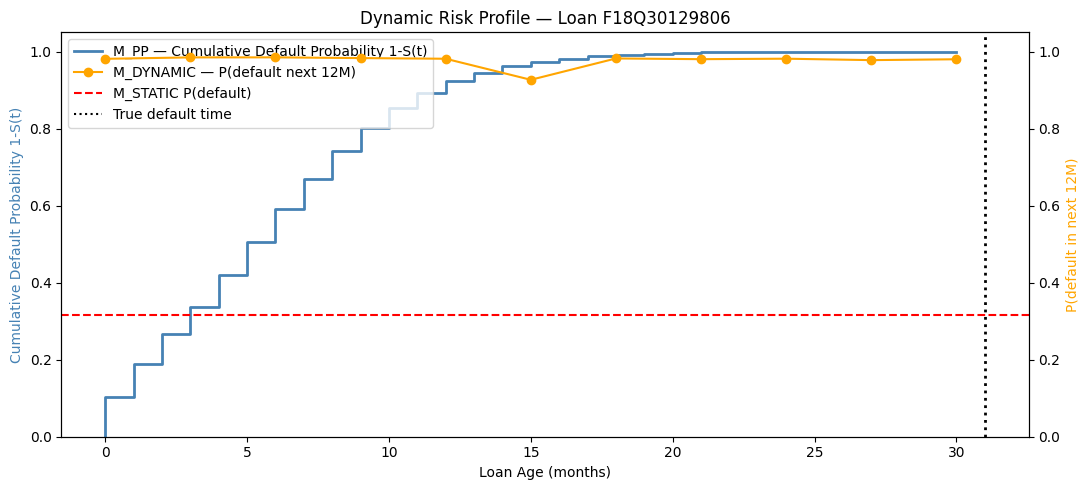

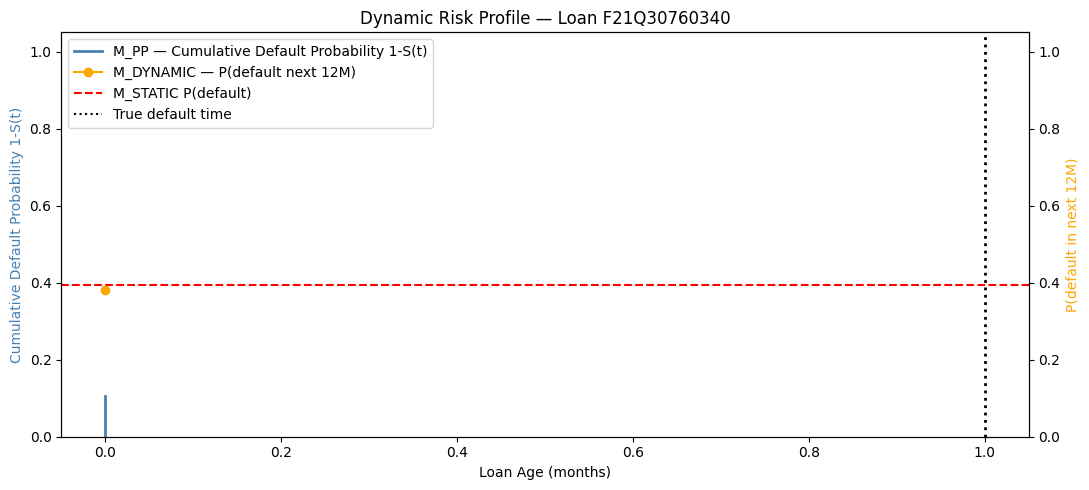

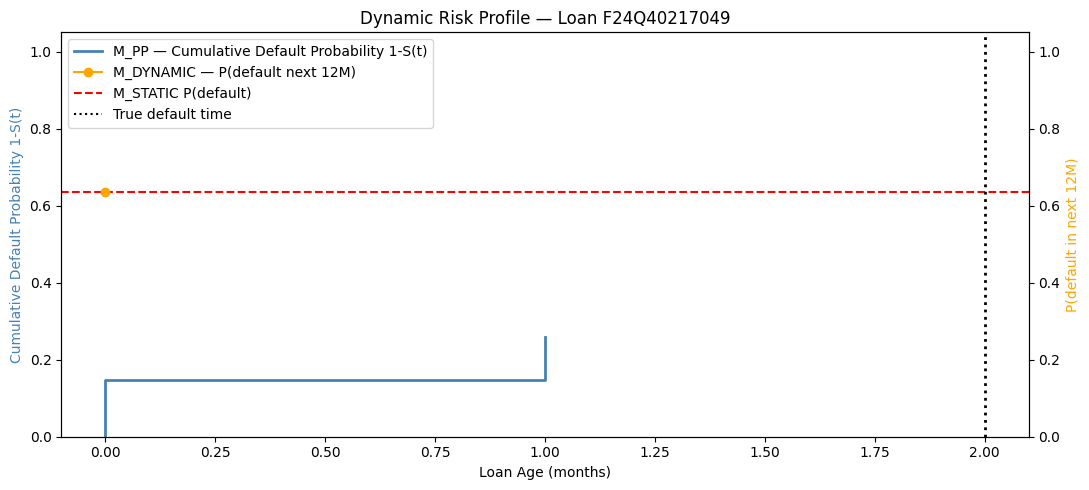

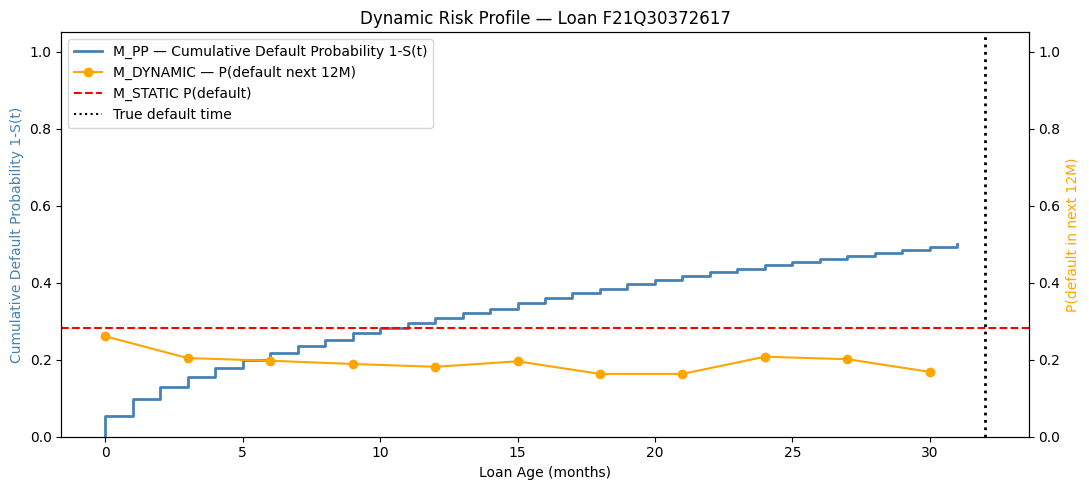

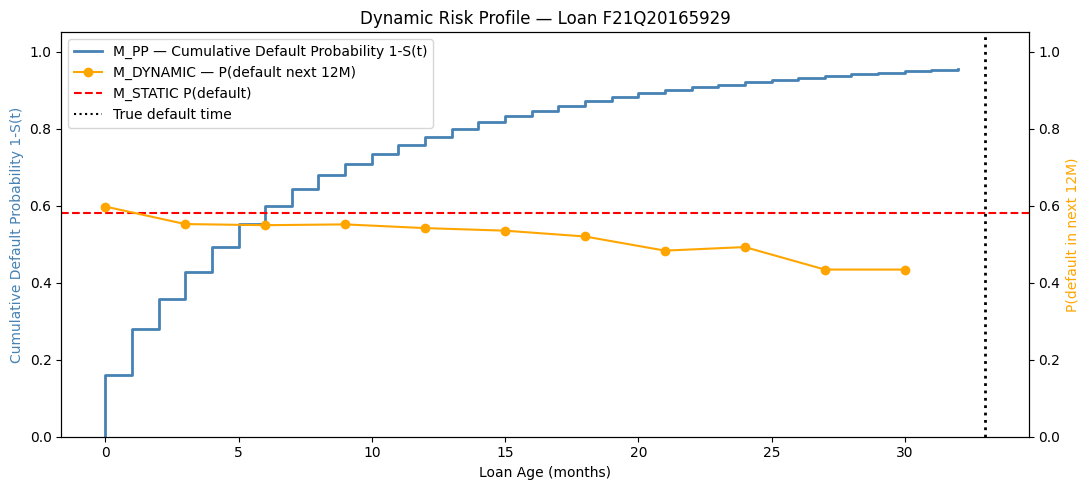

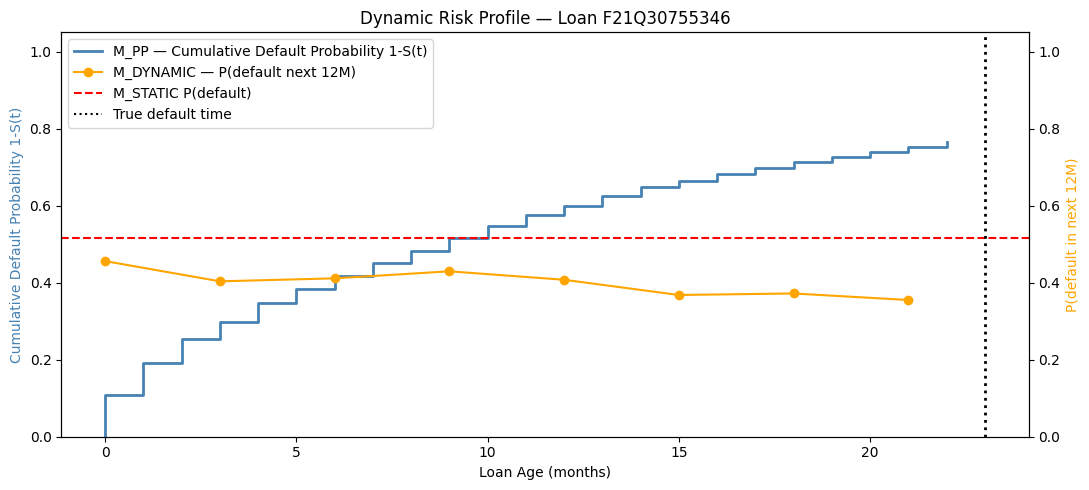

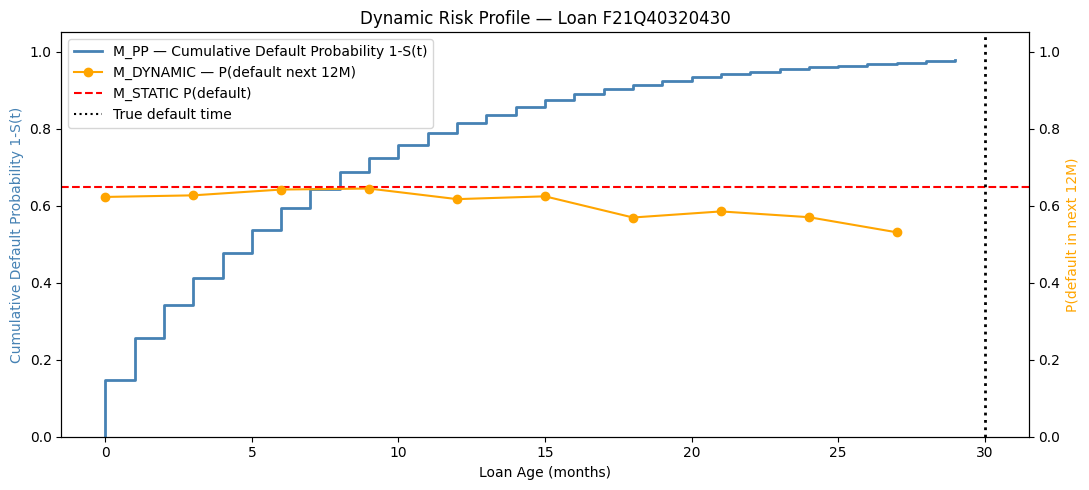

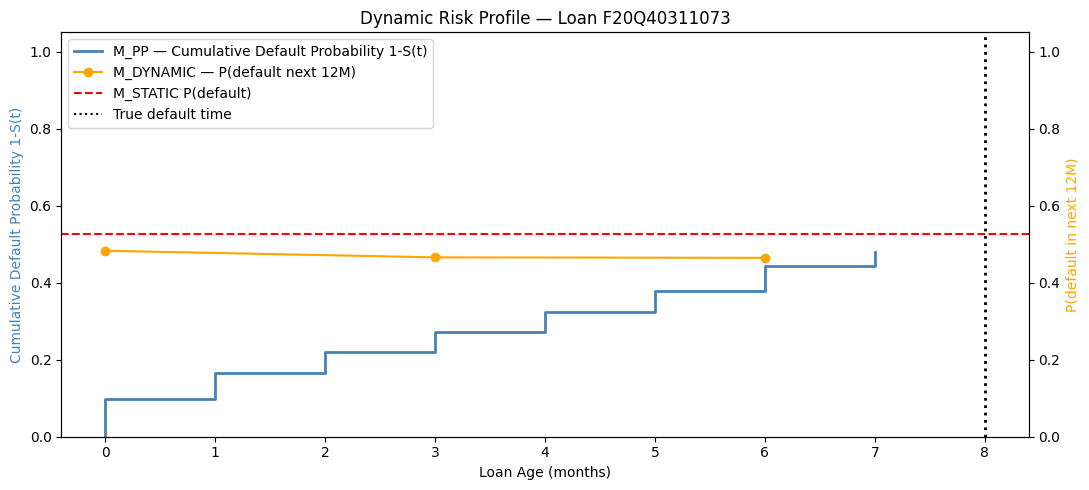

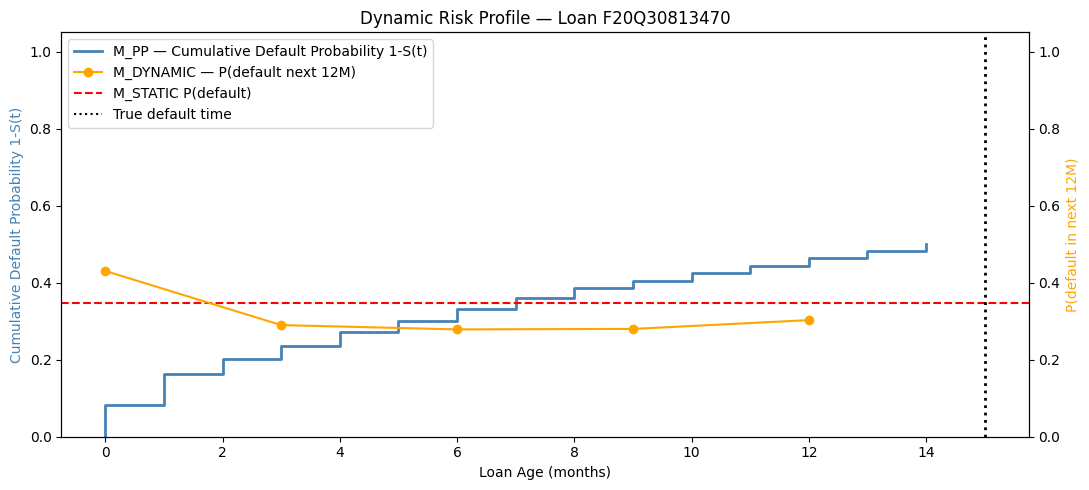

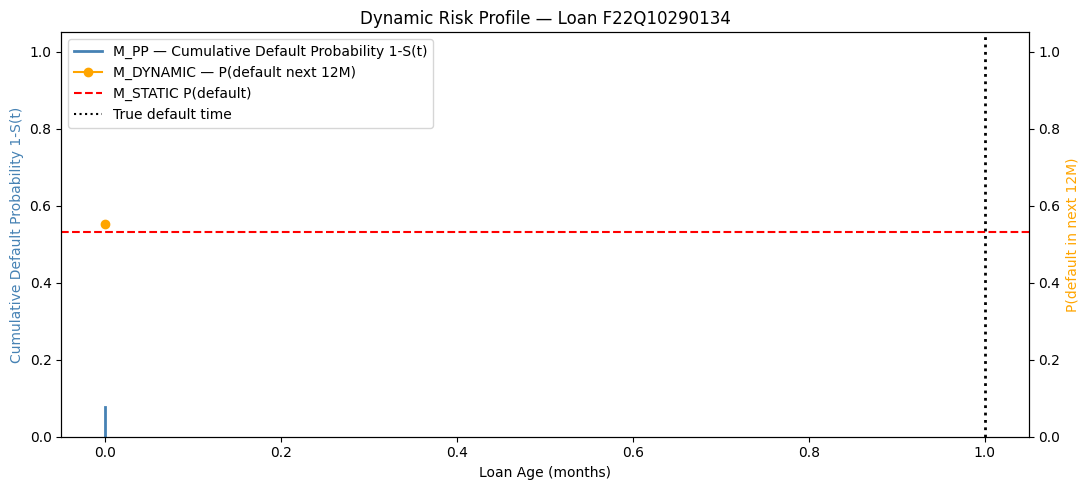


--- LOAN SENZA DEFAULT ---


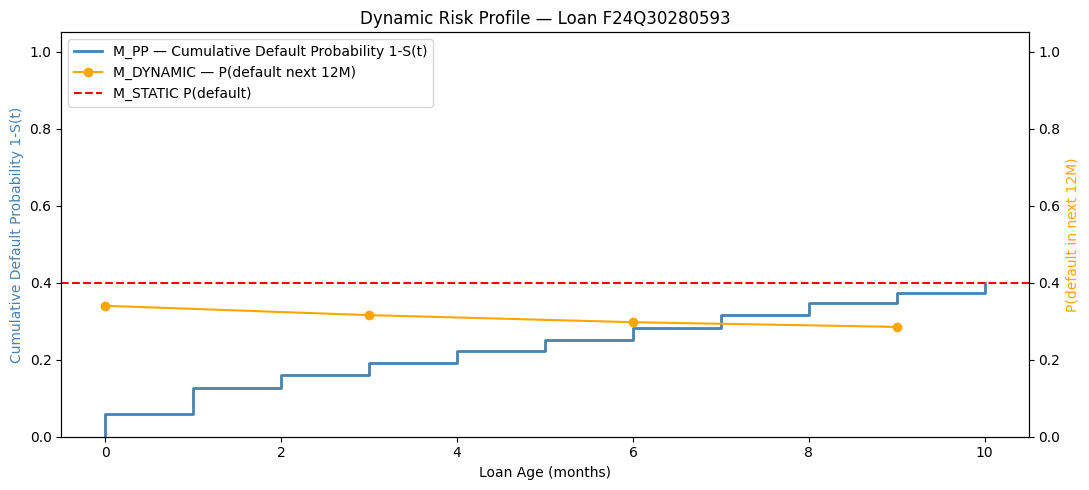

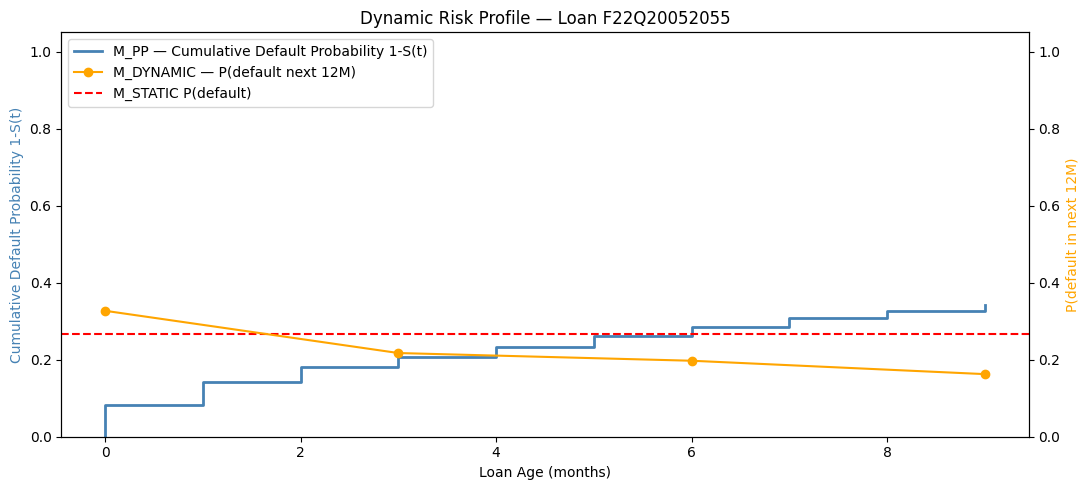

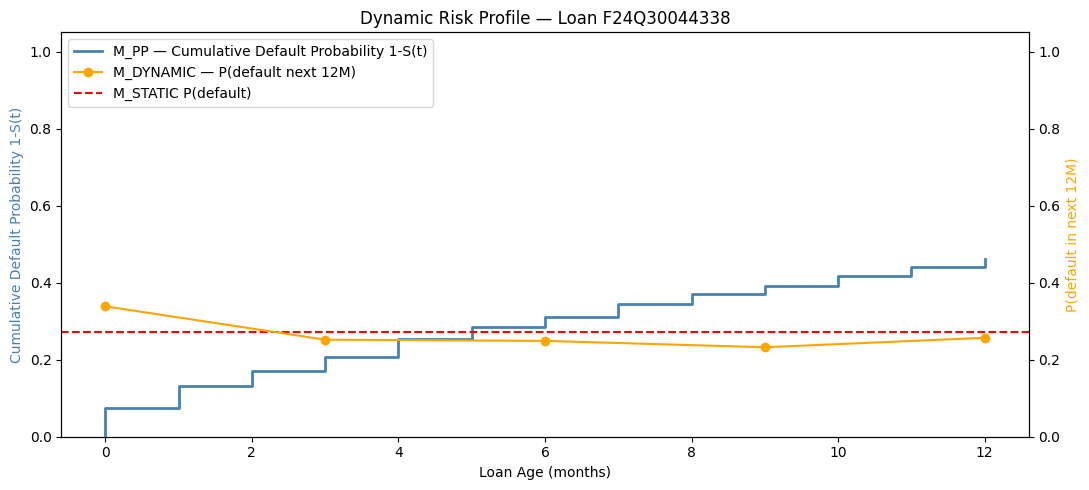

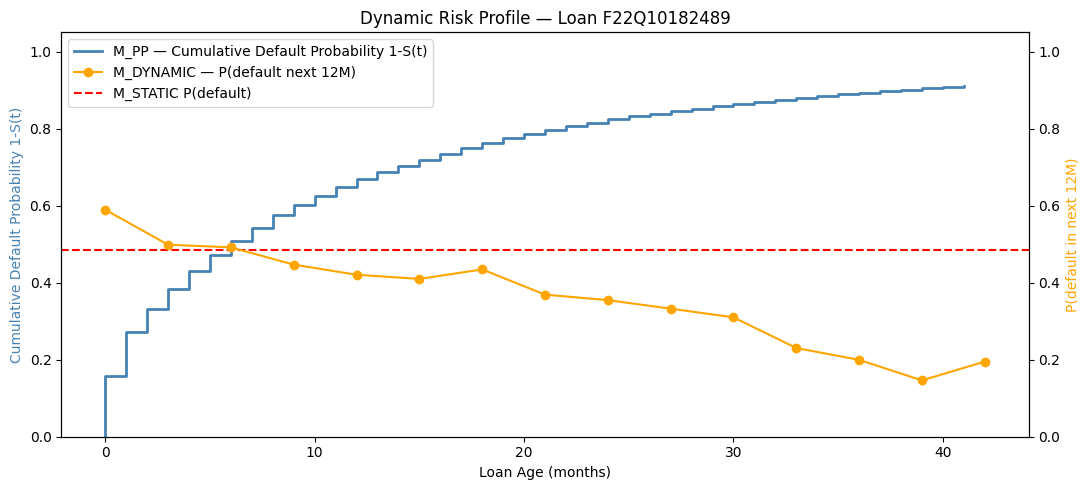

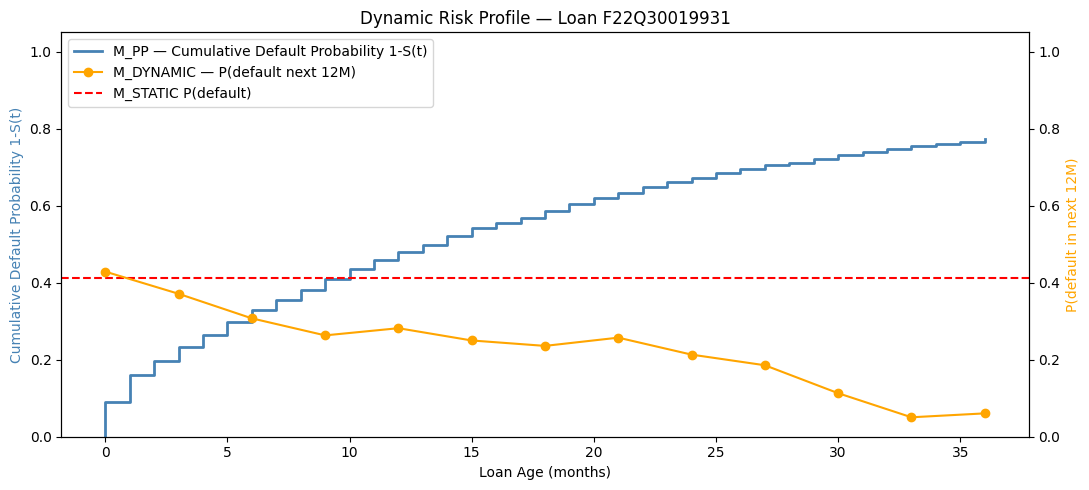

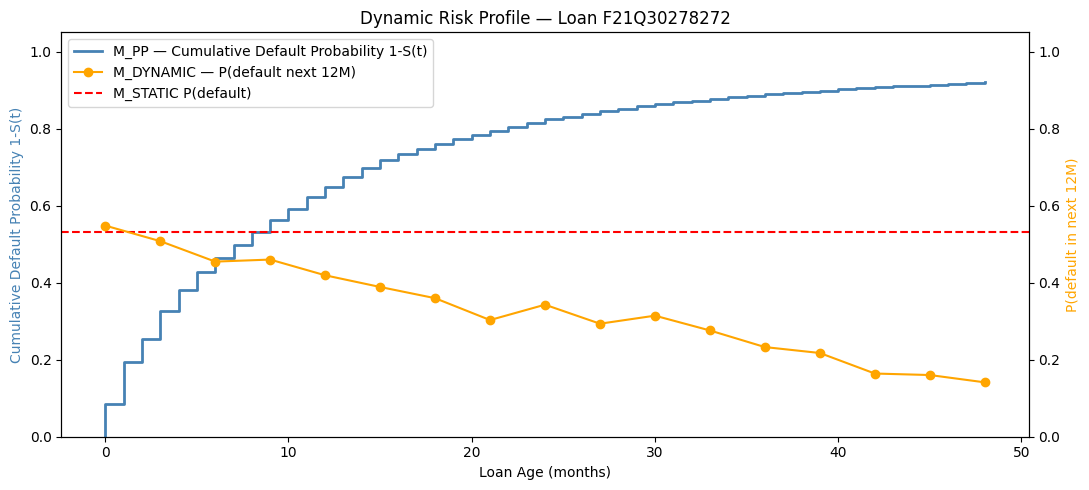

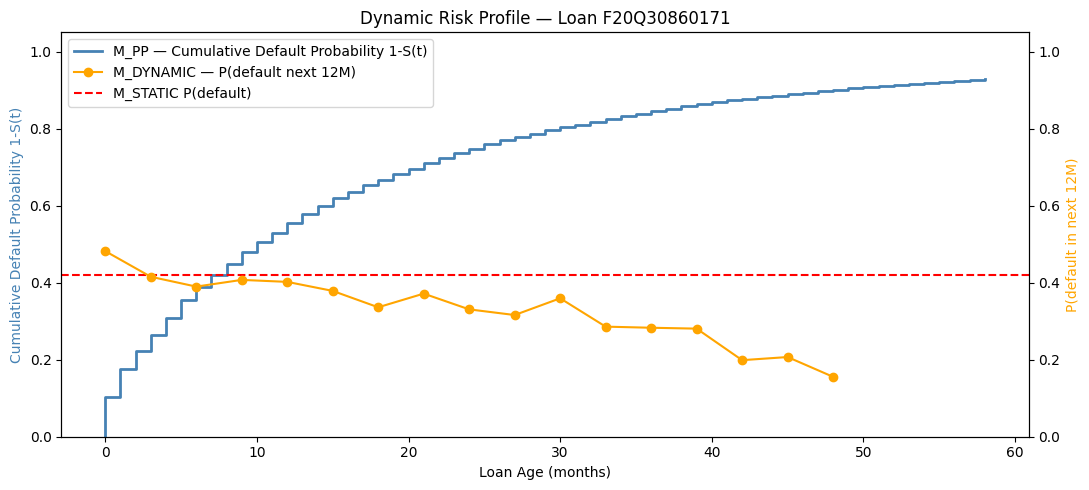

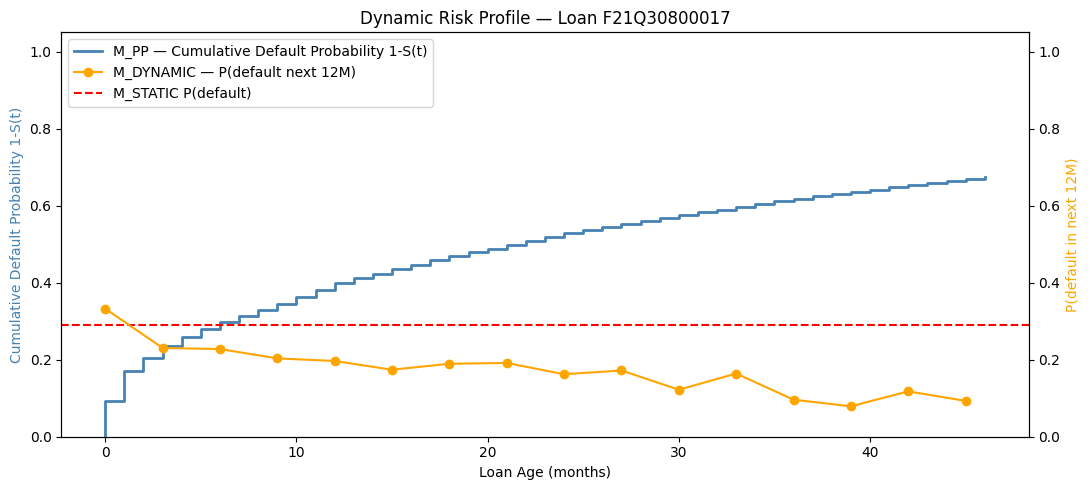

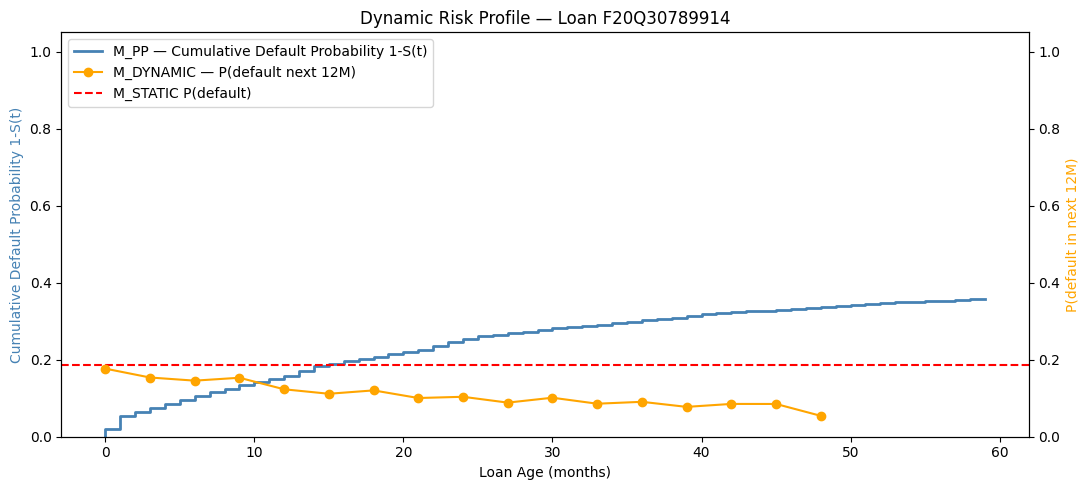

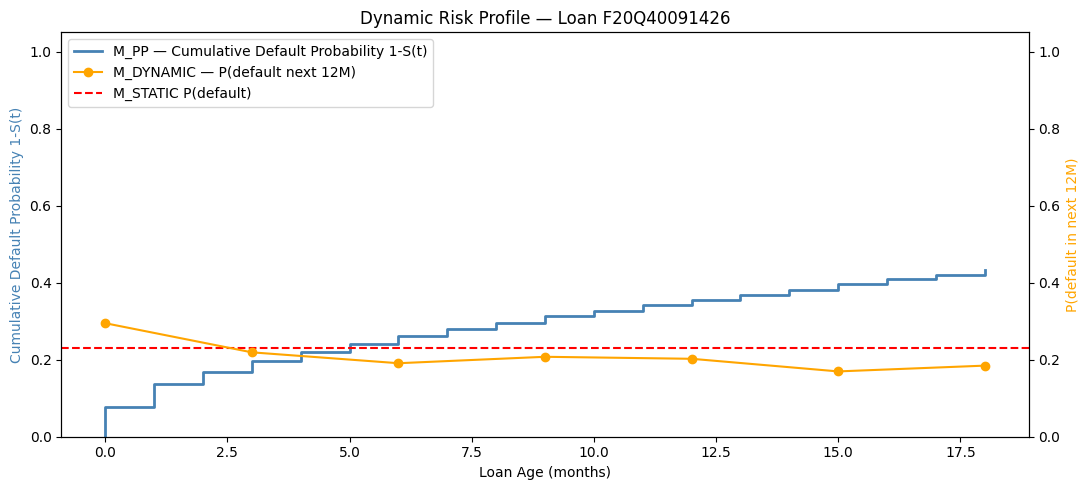

In [3]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import random


# ── Helper functions ───────────────────────────────────────────────────────────

def get_first_default_age(loan_id, truth_df):
    row = truth_df[truth_df["loan_sequence_number"] == loan_id]
    if len(row) == 0:
        return None
    val = row["FirstDefaultAge"].iloc[0]
    return None if pd.isna(val) else float(val)

def get_static_prob(loan_id, grp_ids, preds):
    mask = grp_ids == loan_id
    if mask.sum() == 0:
        raise ValueError(f"Loan {loan_id} not found")
    return float(preds[mask][0])


def plot_loan_dynamic_risk_profile(
    loan_id,
    grp_pp, pp_ages, pp_preds,
    grp_dyn, lmk_vals, dyn_preds,
    static_pd,
    truth_df
):
    # ── TRUE DEFAULT ──────────────────────────────────────────────────────────
    true_default_age = get_first_default_age(loan_id, truth_df)

    # ── M_PP (hazard → cumulative PD) ─────────────────────────────────────────
    mask_pp = grp_pp == loan_id
    hz      = pp_preds[mask_pp]
    ages_pp = pp_ages[mask_pp]

    order   = np.argsort(ages_pp)
    hz      = hz[order]
    ages_pp = ages_pp[order]

    times_pp = np.concatenate([[0], ages_pp])
    surv_pp  = np.concatenate([[1.0], np.cumprod(1 - hz)])
    pd_pp    = 1 - surv_pp

    # ── M_DYNAMIC ─────────────────────────────────────────────────────────────
    mask_dyn = grp_dyn == loan_id
    lm       = lmk_vals[mask_dyn]
    p        = dyn_preds[mask_dyn]

    order_d = np.argsort(lm)
    lm      = lm[order_d]
    p       = p[order_d]

    # ── PLOT ──────────────────────────────────────────────────────────────────
    fig, ax1 = plt.subplots(figsize=(11, 5))

    ax1.step(times_pp, pd_pp, where="post", color="steelblue", lw=2)
    ax1.axhline(static_pd, color="red", linestyle="--", lw=1.5)
    ax1.set_xlabel("Loan Age (months)")
    ax1.set_ylabel("Cumulative Default Probability 1-S(t)", color="steelblue")
    ax1.set_ylim(0, 1.05)

    if true_default_age is not None:
        ax1.axvline(true_default_age, color="black", linestyle=":", lw=2)

    ax2 = ax1.twinx()
    ax2.plot(lm, p, "o-", color="orange", lw=1.5, ms=6)
    ax2.set_ylabel("P(default in next 12M)", color="orange")
    ax2.set_ylim(0, 1.05)

    # ── LEGEND ────────────────────────────────────────────────────────────────
    handles = [
        mlines.Line2D([], [], color="steelblue", lw=2,
                      label="M_PP — Cumulative Default Probability 1-S(t)"),
        mlines.Line2D([], [], color="orange", marker="o",
                      label="M_DYNAMIC — P(default next 12M)"),
        mlines.Line2D([], [], color="red", linestyle="--",
                      label="M_STATIC P(default)"),
    ]
    if true_default_age is not None:
        handles.append(
            mlines.Line2D([], [], color="black", linestyle=":",
                          label="True default time")
        )
    ax1.legend(handles=handles, loc="upper left")

    plt.title(f"Dynamic Risk Profile — Loan {loan_id}")
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"risk_profile_{loan_id}.png", dpi=150)
    plt.show()

# ── Prepara truth_df ───────────────────────────────────────────────────────────
truth_df_raw = pd.read_csv(
    DATA_PATH,
    usecols=["loan_sequence_number", "current_loan_delinquency_status", "loan_age"],
    low_memory=False
)
truth_df_raw["Default"] = is_default_vec(truth_df_raw["current_loan_delinquency_status"])
fd_age   = (truth_df_raw[truth_df_raw["Default"] == 1]
            .groupby("loan_sequence_number")["loan_age"].min()
            .rename("FirstDefaultAge"))
truth_df = truth_df_raw.merge(fd_age.reset_index(), on="loan_sequence_number", how="left")
del truth_df_raw

# ── Candidati ─────────────────────────────────────────────────────────────────
static_loans  = set(grp_static)
pp_loans      = set(grp_pp)
dynamic_loans = set(grp_dynamic)
common_loans  = static_loans & pp_loans & dynamic_loans

defaulted_loans         = set(truth_df.dropna(subset=["FirstDefaultAge"])["loan_sequence_number"])
defaulted_candidates    = list(common_loans & defaulted_loans)
non_defaulted_candidates = list(common_loans - defaulted_loans)

defaulted_candidates     = list(common_loans & defaulted_loans)
non_defaulted_candidates = list(common_loans - defaulted_loans)

# ── Shuffle random ─────────────────────────────────────────────────────────────
import random
random.seed(42)
random.shuffle(defaulted_candidates)
random.shuffle(non_defaulted_candidates)

print(f"Defaulted disponibili:     {len(defaulted_candidates)}")
print(f"Non-defaulted disponibili: {len(non_defaulted_candidates)}")

# ── Plot ───────────────────────────────────────────────────────────────────────
N = 10

print("\n--- LOAN CON DEFAULT ---")
for loan_id in defaulted_candidates[:N]:
    static_pd = get_static_prob(loan_id, grp_static, static_oof_preds)
    plot_loan_dynamic_risk_profile(
        loan_id  = loan_id,
        grp_pp   = grp_pp,   pp_ages  = pp_ages,   pp_preds  = pp_oof_preds,
        grp_dyn  = grp_dynamic, lmk_vals = lmk_vals, dyn_preds = dynamic_oof_preds,
        static_pd = static_pd, truth_df  = truth_df
    )

print("\n--- LOAN SENZA DEFAULT ---")
for loan_id in non_defaulted_candidates[:N]:
    static_pd = get_static_prob(loan_id, grp_static, static_oof_preds)
    plot_loan_dynamic_risk_profile(
        loan_id  = loan_id,
        grp_pp   = grp_pp,   pp_ages  = pp_ages,   pp_preds  = pp_oof_preds,
        grp_dyn  = grp_dynamic, lmk_vals = lmk_vals, dyn_preds = dynamic_oof_preds,
        static_pd = static_pd, truth_df  = truth_df
    )